# Setup

In [1]:
import math
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score, mean_absolute_error

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy import stats
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

import re
from io import StringIO

In [2]:
# =========================
# Estilo global dos plots (bizus.pdf seções 6 e 8)
# =========================
import matplotlib.pyplot as plt

PLOT_STYLE = {
    "font.family": "serif",
    "font.size": 13,
    "axes.titlesize": 14,
    "axes.labelsize": 13,
    "legend.fontsize": 11,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "mathtext.fontset": "cm",
    "lines.linewidth": 2,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "figure.autolayout": True,
}
plt.rcParams.update(PLOT_STYLE)

def T(pt, en, lang):
    """Helper para selecionar string por idioma nos plots PT/EN."""
    return en if lang == "en" else pt


# Dataset

In [3]:
metrics = {
    3:  {"30→15": {"ADE": (1.964, 4.653, 6.273, 68.69), "FDE": (6.268, 12.197, 16.386, 61.74), "MAE": (1.241, 2.938, 3.954, 68.61)},
         "60→30": {"ADE": (12.901, 26.085, 21.508, 40.03), "FDE": (41.303, 72.591, 57.630, 28.31), "MAE": (8.126, 16.456, 13.565, 40.09)}},
    4:  {"30→15": {"ADE": (4.337, 9.313, 14.537, 70.16), "FDE": (13.801, 24.677, 37.869, 63.54), "MAE": (2.754, 5.910, 9.212, 70.10)},
         "60→30": {"ADE": (28.109, 47.993, 51.203, 45.11), "FDE": (88.728, 131.172, 136.732, 35.09), "MAE": (17.777, 30.505, 32.375, 45.11)}},
    5:  {"30→15": {"ADE": (3.929, 10.268, 16.496, 76.18), "FDE": (12.488, 26.591, 43.044, 70.99), "MAE": (2.481, 6.517, 10.399, 76.14)},
         "60→30": {"ADE": (26.096, 54.480, 56.940, 54.17), "FDE": (83.940, 149.762, 154.090, 45.53), "MAE": (16.508, 34.476, 35.840, 53.94)}},
    6:  {"30→15": {"ADE": (4.328, 9.687, 16.324, 73.48), "FDE": (13.770, 25.587, 42.593, 67.67), "MAE": (2.726, 6.168, 10.316, 73.58)},
         "60→30": {"ADE": (28.677, 51.570, 58.208, 50.74), "FDE": (90.723, 142.223, 156.496, 41.99), "MAE": (18.096, 32.819, 36.732, 50.74)}},
    7:  {"30→15": {"ADE": (4.250, 9.190, 14.200, 70.05), "FDE": (13.580, 24.570, 36.910, 63.20), "MAE": (2.680, 5.820, 8.970, 70.14)},
         "60→30": {"ADE": (28.480, 49.820, 49.220, 42.14), "FDE": (90.080, 136.490, 131.070, 31.25), "MAE": (17.990, 31.730, 31.110, 42.19)}},
    8:  {"30→15": {"ADE": (4.660, 10.082, 16.438, 71.64), "FDE": (14.948, 27.108, 42.702, 65.00), "MAE": (2.937, 6.379, 10.389, 71.73)},
         "60→30": {"ADE": (30.762, 52.833, 58.128, 47.07), "FDE": (97.916, 144.563, 154.098, 36.44), "MAE": (19.514, 33.515, 36.788, 46.95)}},
    9:  {"30→15": {"ADE": (7.355, 16.517, 26.686, 72.44), "FDE": (23.812, 44.197, 69.428, 65.71), "MAE": (4.613, 10.450, 16.566, 72.15)},
         "60→30": {"ADE": (48.557, 81.337, 92.449, 47.46), "FDE": (153.854, 221.563, 245.223, 37.25), "MAE": (30.388, 51.418, 57.052, 46.73)}},
    10: {"30→15": {"ADE": (6.850, 13.012, 19.367, 64.64), "FDE": (21.197, 34.951, 49.911, 57.53), "MAE": (4.270, 8.195, 12.179, 64.94)},
         "60→30": {"ADE": (42.091, 61.520, 65.409, 35.66), "FDE": (129.143, 165.721, 173.003, 25.35), "MAE": (26.337, 38.926, 41.018, 35.80)}},
    11: {"30→15": {"ADE": (8.213, 17.719, 29.125, 71.79), "FDE": (26.436, 47.504, 75.388, 64.93), "MAE": (5.181, 11.187, 18.118, 71.41)},
         "60→30": {"ADE": (56.581, 89.451, 97.593, 42.03), "FDE": (176.389, 241.477, 257.086, 31.40), "MAE": (35.320, 56.365, 60.606, 41.71)}},
    12: {"30→15": {"ADE": (6.010, 15.560, 27.090, 77.82), "FDE": (19.640, 41.290, 70.560, 72.17), "MAE": (3.790, 9.850, 16.760, 77.40)},
         "60→30": {"ADE": (42.600, 83.400, 93.740, 54.55), "FDE": (137.350, 228.590, 251.480, 45.39), "MAE": (26.770, 53.110, 57.810, 53.69)}},
    13: {"30→15": {"ADE": (6.090, 14.460, 21.600, 71.80), "FDE": (19.300, 38.520, 56.150, 65.64), "MAE": (3.820, 9.050, 13.150, 70.92)},
         "60→30": {"ADE": (40.080, 72.220, 73.890, 45.77), "FDE": (123.920, 191.090, 195.180, 36.51), "MAE": (24.990, 45.650, 44.980, 44.43)}},
    14: {"30→15": {"ADE": (9.410, 21.540, 31.170, 69.82), "FDE": (30.790, 58.580, 80.130, 61.57), "MAE": (5.980, 13.680, 19.700, 69.67)},
         "60→30": {"ADE": (66.980, 105.650, 104.310, 35.78), "FDE": (209.540, 284.260, 270.870, 22.64), "MAE": (42.520, 67.190, 66.060, 35.63)}},
    15: {"30→15": {"ADE": (4.830, 11.720, 20.170, 76.05), "FDE": (15.560, 30.980, 52.530, 70.37), "MAE": (3.070, 7.410, 12.760, 75.92)},
         "60→30": {"ADE": (33.920, 65.790, 70.720, 52.03), "FDE": (109.540, 182.430, 189.850, 42.30), "MAE": (21.540, 41.850, 44.620, 51.71)}},
    16: {"30→15": {"ADE": (5.170, 13.240, 23.320, 77.82), "FDE": (17.020, 35.150, 60.750, 71.98), "MAE": (3.290, 8.430, 14.730, 77.66)},
         "60→30": {"ADE": (39.740, 68.950, 81.840, 51.43), "FDE": (128.830, 191.740, 218.970, 41.15), "MAE": (25.290, 43.690, 51.740, 51.13)}},
    17: {"30→15": {"ADE": (4.920, 12.550, 20.520, 76.03), "FDE": (15.930, 33.260, 53.590, 70.28), "MAE": (3.120, 7.950, 12.970, 75.95)},
         "60→30": {"ADE": (35.330, 65.400, 71.480, 50.58), "FDE": (113.670, 181.010, 192.490, 40.94), "MAE": (22.340, 41.790, 45.150, 50.53)}},
    18: {"30→15": {"ADE": (5.320, 13.550, 20.980, 74.62), "FDE": (17.350, 35.790, 54.560, 68.20), "MAE": (3.380, 8.580, 13.300, 74.62)},
         "60→30": {"ADE": (37.980, 72.050, 71.730, 47.05), "FDE": (122.110, 198.580, 190.540, 35.94), "MAE": (24.110, 45.720, 45.470, 46.98)}},
    19: {"30→15": {"ADE": (5.020, 12.620, 20.320, 75.32), "FDE": (16.280, 33.180, 52.910, 69.23), "MAE": (3.190, 8.030, 12.900, 75.26)},
         "60→30": {"ADE": (35.420, 66.780, 70.850, 50.00), "FDE": (113.930, 183.790, 190.440, 40.17), "MAE": (22.590, 42.400, 45.050, 49.84)}},
    20: {"30→15": {"ADE": (4.850, 11.960, 20.210, 76.02), "FDE": (15.790, 31.670, 52.680, 70.02), "MAE": (3.070, 7.560, 12.730, 75.93)},
         "60→30": {"ADE": (34.830, 62.550, 69.470, 49.88), "FDE": (111.910, 174.250, 186.320, 39.95), "MAE": (22.030, 39.850, 43.740, 49.64)}},
    21: {"30→15": {"ADE": (4.710, 12.660, 21.830, 78.45), "FDE": (15.340, 33.280, 57.000, 73.08), "MAE": (2.980, 8.030, 13.750, 78.32)},
         "60→30": {"ADE": (33.760, 68.870, 75.730, 55.43), "FDE": (109.600, 189.930, 204.770, 46.49), "MAE": (21.390, 43.840, 47.660, 55.13)}},
    22: {"30→15": {"ADE": (5.130, 13.250, 24.110, 78.73), "FDE": (16.850, 35.240, 62.870, 73.20), "MAE": (3.260, 8.420, 15.210, 78.59)},
         "60→30": {"ADE": (38.150, 71.160, 83.140, 54.12), "FDE": (124.860, 197.350, 222.900, 43.98), "MAE": (24.190, 45.360, 52.550, 53.95)}},
    23: {"30→15": {"ADE": (4.950, 13.610, 23.170, 78.63), "FDE": (16.050, 35.530, 60.530, 73.48), "MAE": (3.140, 8.690, 14.640, 78.55)},
         "60→30": {"ADE": (35.400, 74.890, 80.390, 55.96), "FDE": (115.390, 206.270, 216.510, 46.70), "MAE": (22.460, 47.720, 50.890, 55.86)}},
    24: {"30→15": {"ADE": (5.170, 13.210, 21.130, 75.56), "FDE": (16.800, 34.900, 54.940, 69.41), "MAE": (3.270, 8.400, 13.300, 75.45)},
         "60→30": {"ADE": (36.200, 69.400, 72.460, 50.03), "FDE": (116.760, 191.710, 192.960, 39.49), "MAE": (22.990, 44.190, 45.580, 49.56)}},
    25: {"30→15": {"ADE": (5.060, 12.170, 21.180, 76.11), "FDE": (16.580, 32.490, 54.930, 69.83), "MAE": (3.210, 7.750, 13.390, 76.06)},
         "60→30": {"ADE": (37.570, 65.130, 72.840, 48.43), "FDE": (120.890, 178.840, 193.190, 37.43), "MAE": (23.760, 41.490, 45.980, 48.33)}},
    26: {"30→15": {"ADE": (4.980, 12.550, 20.520, 75.73), "FDE": (16.180, 33.270, 53.540, 69.78), "MAE": (3.150, 7.990, 12.940, 75.69)},
         "60→30": {"ADE": (35.100, 68.400, 71.550, 50.93), "FDE": (112.600, 189.030, 191.700, 41.27), "MAE": (22.220, 43.430, 44.980, 50.60)}},
    27: {"30→15": {"ADE": (5.470, 13.001, 20.333, 73.10), "FDE": (17.493, 33.889, 53.083, 67.05), "MAE": (3.505, 8.268, 12.941, 72.92)},
         "60→30": {"ADE": (37.179, 71.024, 72.644, 48.80), "FDE": (118.179, 194.723, 195.596, 39.58), "MAE": (23.726, 45.240, 46.256, 48.70)}},
    28: {"30→15": {"ADE": (4.980, 11.856, 18.490, 73.06), "FDE": (15.794, 30.938, 48.280, 67.29), "MAE": (3.148, 7.544, 11.676, 73.04)},
         "60→30": {"ADE": (32.016, 66.254, 65.344, 50.99), "FDE": (101.876, 183.372, 176.940, 42.42), "MAE": (20.314, 42.324, 41.370, 50.89)}},
    29: {"30→15": {"ADE": (4.218, 10.983, 16.583, 74.56), "FDE": (13.530, 28.686, 43.333, 68.78), "MAE": (2.669, 6.980, 10.430, 74.41)},
         "60→30": {"ADE": (29.580, 57.242, 57.829, 48.86), "FDE": (94.358, 158.016, 156.438, 39.66), "MAE": (18.734, 36.497, 36.508, 48.68)}},
    30: {"30→15": {"ADE": (4.378, 12.064, 19.370, 77.40), "FDE": (14.237, 31.562, 50.686, 71.91), "MAE": (2.774, 7.656, 12.206, 77.27)},
         "60→30": {"ADE": (31.450, 66.114, 67.759, 53.59), "FDE": (101.869, 180.925, 183.277, 44.43), "MAE": (19.942, 41.912, 42.544, 53.13)}},
    31: {"30→15": {"ADE": (4.080, 11.281, 17.929, 77.24), "FDE": (13.108, 29.177, 46.918, 72.06), "MAE": (2.593, 7.158, 11.303, 77.06)},
         "60→30": {"ADE": (29.600, 61.136, 62.620, 52.73), "FDE": (95.857, 170.546, 169.694, 43.51), "MAE": (18.829, 38.770, 39.624, 52.48)}},
    32: {"30→15": {"ADE": (4.052, 11.403, 18.165, 77.69), "FDE": (13.080, 29.636, 47.527, 72.48), "MAE": (2.580, 7.226, 11.480, 77.53)},
         "60→30": {"ADE": (29.324, 62.862, 63.377, 53.73), "FDE": (95.570, 175.040, 171.458, 44.26), "MAE": (18.646, 39.983, 40.073, 53.46)}},
    33: {"30→15": {"ADE": (4.115, 11.137, 18.948, 78.28), "FDE": (13.305, 29.327, 49.621, 73.19), "MAE": (2.608, 7.078, 12.016, 78.29)},
         "60→30": {"ADE": (30.257, 63.252, 67.902, 55.44), "FDE": (99.078, 174.494, 184.077, 46.18), "MAE": (19.170, 40.175, 42.989, 55.41)}},
    34: {"30→15": {"ADE": (4.773, 12.667, 21.123, 77.40), "FDE": (15.436, 33.287, 55.135, 72.01), "MAE": (3.032, 8.067, 13.439, 77.44)},
         "60→30": {"ADE": (35.053, 69.927, 73.714, 52.45), "FDE": (114.857, 194.106, 199.002, 42.29), "MAE": (22.402, 44.505, 47.125, 52.46)}},
    35: {"30→15": {"ADE": (4.664, 12.000, 18.693, 75.05), "FDE": (15.104, 31.614, 48.793, 69.05), "MAE": (2.955, 7.629, 11.787, 74.93)},
         "60→30": {"ADE": (33.183, 66.063, 64.570, 48.61), "FDE": (106.667, 181.791, 173.235, 38.43), "MAE": (21.091, 41.986, 40.849, 48.37)}},
    36: {"30→15": {"ADE": (4.040, 11.010, 17.205, 76.52), "FDE": (12.853, 28.156, 45.008, 71.44), "MAE": (2.561, 6.968, 10.923, 76.55)},
         "60→30": {"ADE": (27.346, 60.365, 59.794, 54.27), "FDE": (88.606, 167.719, 162.994, 45.64), "MAE": (17.323, 38.416, 37.963, 54.36)}},
    37: {"30→15": {"ADE": (4.437, 12.562, 19.945, 77.75), "FDE": (14.177, 32.335, 52.209, 72.84), "MAE": (2.806, 7.968, 12.609, 77.75)},
         "60→30": {"ADE": (31.548, 69.070, 70.033, 54.95), "FDE": (102.276, 190.331, 190.329, 46.26), "MAE": (20.079, 43.988, 44.493, 54.87)}},
    38: {"30→15": {"ADE": (3.972, 9.839, 15.186, 73.84), "FDE": (12.941, 26.294, 39.614, 67.33), "MAE": (2.519, 6.251, 9.647, 73.89)},
         "60→30": {"ADE": (29.412, 53.819, 52.465, 43.94), "FDE": (94.344, 147.825, 140.785, 32.99), "MAE": (18.771, 34.229, 33.292, 43.62)}},
}

meta_rows = [
    {"year": 2019, "dataset": 1,  "log_file": "2019-07-05_06-15_RoboTeam_Twente-vs-RoboDragons.log", "teams": "RoboTeam_Twente vs RoboDragons", "description": "Treino",       "ade_30_15": np.nan, "ade_60_30": np.nan, "perf_30_15_pct": np.nan, "perf_60_30_pct": np.nan},
    {"year": 2019, "dataset": 2,  "log_file": "2019-07-07_05-26_ER-Force-vs-MRL.log",                "teams": "ER-Force vs MRL",                  "description": "Treino",       "ade_30_15": np.nan, "ade_60_30": np.nan, "perf_30_15_pct": np.nan, "perf_60_30_pct": np.nan},
    {"year": 2019, "dataset": 3,  "log_file": "2019-07-04_06-55_KIKS-vs-TIGERs_Mannheim.log",         "teams": "KIKS vs TIGERs_Mannheim",          "description": "0 Conhecidos",  "ade_30_15": 1.96,   "ade_60_30": 12.90,  "perf_30_15_pct": 68.69, "perf_60_30_pct": 40.03},
    {"year": 2019, "dataset": 4,  "log_file": "2019-07-07_01-49_RoboTeam_Twente-vs-MRL.log",          "teams": "RoboTeam_Twente vs MRL",           "description": "1 Conhecido",   "ade_30_15": 4.34,   "ade_60_30": 28.11,  "perf_30_15_pct": 70.16, "perf_60_30_pct": 45.11},
    {"year": 2019, "dataset": 5,  "log_file": "2019-07-04_12-15_ZJUNlict-vs-RoboTeam_Twente.log",    "teams": "RoboTeam_Twente vs ZJUNlict",      "description": "2 Conhecidos",  "ade_30_15": 3.93,   "ade_60_30": 26.10,  "perf_30_15_pct": 76.18, "perf_60_30_pct": 54.17},
    {"year": 2019, "dataset": 6,  "log_file": "2019-07-04_14-10_KIKS-vs-MRL.log",                     "teams": "KIKS vs MRL",                      "description": "1 Conhecido",   "ade_30_15": 4.33,   "ade_60_30": 28.68,  "perf_30_15_pct": 73.48, "perf_60_30_pct": 50.74},
    {"year": 2019, "dataset": 7,  "log_file": "2019-07-05_04-18_KIKS-vs-OP-AmP.log",                  "teams": "KIKS vs OP-AmP",                   "description": "0 Conhecidos",  "ade_30_15": 4.25,   "ade_60_30": 28.48,  "perf_30_15_pct": 70.05, "perf_60_30_pct": 42.14},
    {"year": 2019, "dataset": 8,  "log_file": "2019-07-06_03-11_KIKS-vs-ZJUNlict.log",                "teams": "KIKS vs ZJUNlict",                 "description": "0 Conhecidos",  "ade_30_15": 4.66,   "ade_60_30": 30.76,  "perf_30_15_pct": 71.64, "perf_60_30_pct": 47.07},

    {"year": 2021, "dataset": 9,  "log_file": "2021-06-21_09-01_TIGERs_Mannheim-vs-KIKS.log",         "teams": "TIGERs vs KIKS",                   "description": "0 Conhecidos",  "ade_30_15": 7.36,   "ade_60_30": 48.56,  "perf_30_15_pct": 72.44, "perf_60_30_pct": 47.46},
    {"year": 2021, "dataset": 10, "log_file": "2021-06-24_13-10_OMID-vs-RoboJackets.log",             "teams": "OMID vs RoboJackets",              "description": "0 Conhecidos",  "ade_30_15": 6.85,   "ade_60_30": 42.09,  "perf_30_15_pct": 64.64, "perf_60_30_pct": 35.66},
    {"year": 2021, "dataset": 11, "log_file": "2021-06-20_14-43_KIKS-vs-RoboDragons.log",             "teams": "KIKS vs RoboDragons",              "description": "1 Conhecido",   "ade_30_15": 8.21,   "ade_60_30": 56.58,  "perf_30_15_pct": 71.79, "perf_60_30_pct": 42.03},
    {"year": 2021, "dataset": 12, "log_file": "2021-06-24_14-36_ER-Force-vs-TIGERs_Mannheim.log",     "teams": "ER-Force vs TIGERs",               "description": "1 Conhecido",   "ade_30_15": 6.01,   "ade_60_30": 42.60,  "perf_30_15_pct": 77.82, "perf_60_30_pct": 54.55},
    {"year": 2021, "dataset": 13, "log_file": "2021-06-21_07-06_RoboTeam_Twente-vs-ER-Force.log",     "teams": "RoboTeam_Twente vs ER-Force",      "description": "2 Conhecidos",  "ade_30_15": 6.09,   "ade_60_30": 40.08,  "perf_30_15_pct": 71.80, "perf_60_30_pct": 45.77},
    {"year": 2021, "dataset": 14, "log_file": "2021-06-30_20-01_TIGERs_Mannheim-vs-RoboFEI.log",      "teams": "TIGERs_Mannheim vs RoboFEI",       "description": "0 Conhecidos",  "ade_30_15": 9.41,   "ade_60_30": 66.98,  "perf_30_15_pct": 69.82, "perf_60_30_pct": 35.78},

    {"year": 2023, "dataset": 15, "log_file": "2023-07-06_12-47_RoboTeam_Twente-vs-RoboDragons.log",  "teams": "RoboTeam_Twente vs RoboDragons",   "description": "2 Conhecidos",  "ade_30_15": 4.83,   "ade_60_30": 33.92,  "perf_30_15_pct": 76.05, "perf_60_30_pct": 52.03},
    {"year": 2023, "dataset": 16, "log_file": "2023-07-08_11-01_ZJUNlict-vs-RoboDragons.log",         "teams": "ZJUNlict vs RoboDragons",          "description": "1 Conhecido",   "ade_30_15": 5.17,   "ade_60_30": 39.74,  "perf_30_15_pct": 77.82, "perf_60_30_pct": 51.43},
    {"year": 2023, "dataset": 17, "log_file": "2023-07-08_09-11_RoboTeam_Twente-vs-KIKS.log",         "teams": "RoboTeam_Twente vs KIKS",          "description": "1 Conhecido",   "ade_30_15": 4.92,   "ade_60_30": 35.33,  "perf_30_15_pct": 76.03, "perf_60_30_pct": 50.58},
    {"year": 2023, "dataset": 18, "log_file": "2023-07-08_17-03_ZJUNlict-vs-TIGERs_Mannheim.log",     "teams": "ZJUNlict vs TIGERs_Mannheim",      "description": "0 Conhecidos",  "ade_30_15": 5.32,   "ade_60_30": 37.98,  "perf_30_15_pct": 74.62, "perf_60_30_pct": 47.05},
    {"year": 2023, "dataset": 19, "log_file": "2023-07-08_18-31_Immortals-vs-KIKS.log",               "teams": "Immortals vs KIKS",                "description": "0 Conhecidos",  "ade_30_15": 5.02,   "ade_60_30": 35.42,  "perf_30_15_pct": 75.32, "perf_60_30_pct": 50.00},
    {"year": 2023, "dataset": 20, "log_file": "2023-07-09_13-02_TIGERs_Mannheim-vs-ZJUNlict.log",     "teams": "TIGERs_Mannheim vs ZJUNlict",      "description": "0 Conhecidos",  "ade_30_15": 4.85,   "ade_60_30": 34.83,  "perf_30_15_pct": 76.02, "perf_60_30_pct": 49.88},

    {"year": 2025, "dataset": 21, "log_file": "2025-07-19_15-05_ELIMINATION_PHASE_ER-Force-vs-RoboDragons.log", "teams": "ER-Force vs RoboDragons",          "description": "2 Conhecidos",  "ade_30_15": 4.71, "ade_60_30": 33.76, "perf_30_15_pct": 78.45, "perf_60_30_pct": 55.43},
    {"year": 2025, "dataset": 22, "log_file": "2025-07-17_21-33_GROUP_PHASE_RoboDragons-vs-ZJUNlict.log",       "teams": "RoboDragons vs ZJUNlict",          "description": "1 Conhecido",   "ade_30_15": 5.13, "ade_60_30": 38.15, "perf_30_15_pct": 78.73, "perf_60_30_pct": 54.12},
    {"year": 2025, "dataset": 23, "log_file": "2025-07-17_17-01_GROUP_PHASE_TIGERs_Mannheim-vs-RoboDragons.log","teams": "TIGERs_Mannheim vs RoboDragons",   "description": "1 Conhecido",   "ade_30_15": 4.95, "ade_60_30": 35.40, "perf_30_15_pct": 78.63, "perf_60_30_pct": 55.96},
    {"year": 2025, "dataset": 24, "log_file": "2025-07-18_19-02_GROUP_PHASE_TIGERs_Mannheim-vs-ZJUNlict.log",   "teams": "TIGERs_Mannheim vs ZJUNlict",      "description": "0 Conhecidos",  "ade_30_15": 5.17, "ade_60_30": 36.20, "perf_30_15_pct": 75.56, "perf_60_30_pct": 50.03},
    {"year": 2025, "dataset": 25, "log_file": "2025-07-19_13-32_ELIMINATION_PHASE_RobôCin-vs-ZJUNlict.log",      "teams": "RobôCin vs ZJUNlict",              "description": "0 Conhecidos",  "ade_30_15": 5.06, "ade_60_30": 37.57, "perf_30_15_pct": 76.11, "perf_60_30_pct": 48.43},
    {"year": 2025, "dataset": 26, "log_file": "2025-07-20_15-31_ELIMINATION_PHASE_TIGERs_Mannheim-vs-ZJUNlict.log","teams": "TIGERs_Mannheim vs ZJUNlict",     "description": "0 Conhecidos",  "ade_30_15": 4.98, "ade_60_30": 35.10, "perf_30_15_pct": 75.73, "perf_60_30_pct": 50.93},

    {"year": 2022, "dataset": 27, "log_file": "2022-07-13_09-12_RoboDragons-vs-ER-Force.log",          "teams": "RoboDragons vs ER Force",          "description": "2 Conhecidos",  "ade_30_15": 5.47, "ade_60_30": 37.18, "perf_30_15_pct": 73.10, "perf_60_30_pct": 48.80},
    {"year": 2022, "dataset": 28, "log_file": "2022-07-13_10-49_RoboTeam_Twente-vs-TIGERs_Mannheim.log","teams": "RoboTeam_Twente vs TIGERs_Mannheim","description":"1 Conhecido",   "ade_30_15": 4.98, "ade_60_30": 32.02, "perf_30_15_pct": 73.10, "perf_60_30_pct": 50.99},
    {"year": 2022, "dataset": 29, "log_file": "2022-07-13_12-10_KIKS-vs-ER-Force.log",                 "teams": "KIKS vs ER Force",                 "description": "1 Conhecido",   "ade_30_15": 4.22, "ade_60_30": 29.58, "perf_30_15_pct": 74.55, "perf_60_30_pct": 48.86},
    {"year": 2022, "dataset": 30, "log_file": "2022-07-16_11-34_TIGERs_Mannheim-vs-ER-Force",          "teams": "TIGERs_Mannheim vs ER Force",      "description": "1 Conhecidos",  "ade_30_15": 4.38, "ade_60_30": 31.45, "perf_30_15_pct": 77.40, "perf_60_30_pct": 53.59},
    {"year": 2022, "dataset": 31, "log_file": "2022-07-14_10-55_TIGERs_Mannheim-vs-KIKS.log",          "teams": "TIGERs_Mannheim vs KIKS",          "description": "0 Conhecidos",  "ade_30_15": 4.08, "ade_60_30": 29.60, "perf_30_15_pct": 77.24, "perf_60_30_pct": 52.73},
    {"year": 2022, "dataset": 32, "log_file": "2022-07-15_12-08_TIGERs_Mannheim-vs-KIKS.log",          "teams": "TIGERs_Mannheim vs KIKS",          "description": "0 Conhecidos",  "ade_30_15": 4.05, "ade_60_30": 29.32, "perf_30_15_pct": 77.71, "perf_60_30_pct": 53.74},

    {"year": 2024, "dataset": 33, "log_file": "2024-07-20_13-16_ELIMINATION_PHASE_RoboDragons-vs-ER-Force.log", "teams": "RoboDragons vs ER Force",         "description": "2 Conhecidos",  "ade_30_15": 4.12, "ade_60_30": 30.26, "perf_30_15_pct": 78.26, "perf_60_30_pct": 55.43},
    {"year": 2024, "dataset": 34, "log_file": "2024-07-18_11-33_GROUP_PHASE_RoboDragons-vs-Immortals.log",      "teams": "RoboDragons vs Immortals",        "description": "1 Conhecido",   "ade_30_15": 4.77, "ade_60_30": 35.05, "perf_30_15_pct": 77.41, "perf_60_30_pct": 52.45},
    {"year": 2024, "dataset": 35, "log_file": "2024-07-21_11-00_ELIMINATION_PHASE_ZJUNlict-vs-TIGERs_Mannheim.log","teams": "ZJUNlict vs TIGERs_Mannheim",    "description": "1 Conhecido",   "ade_30_15": 4.66, "ade_60_30": 33.18, "perf_30_15_pct": 75.07, "perf_60_30_pct": 48.61},
    {"year": 2024, "dataset": 36, "log_file": "2024-07-18_10-01_GROUP_PHASE_TIGERs_Mannheim-vs-RoboTeam_Twente.log","teams": "Mannheim vs RoboTeam_Twente",  "description": "1 Conhecidos",  "ade_30_15": 4.04, "ade_60_30": 27.35, "perf_30_15_pct": 76.51, "perf_60_30_pct": 54.26},
    {"year": 2024, "dataset": 37, "log_file": "2024-07-18_16-01_GROUP_PHASE_TIGERs_Mannheim-vs-Immortals.log",  "teams": "TIGERs_Mannheim vs Immortals",    "description": "0 Conhecidos",  "ade_30_15": 4.44, "ade_60_30": 31.55, "perf_30_15_pct": 77.74, "perf_60_30_pct": 54.95},
    {"year": 2024, "dataset": 38, "log_file": "2024-07-18_07-01_GROUP_PHASE_KIKS-vs-RobôCin.log",               "teams": "KIKS vs RobôCin",                 "description": "0 Conhecidos",  "ade_30_15": 3.97, "ade_60_30": 29.41, "perf_30_15_pct": 73.86, "perf_60_30_pct": 43.94},
]

txt = """file\tyear\tfeature\tks\twasserstein
proc_set_3.pkl\t2019\tspeed\t0.0472682531786687\t1.0527796810989751
proc_set_3.pkl\t2019\taccel\t0.045107643522671936\t0.04488226360843087
proc_set_3.pkl\t2019\tturn\t0.05726749192938829\t0.006761042911388865
proc_set_4.pkl\t2019\tspeed\t0.13663903531250704\t1.8577227211637841
proc_set_4.pkl\t2019\taccel\t0.11510046013008912\t0.04250163476363239
proc_set_4.pkl\t2019\tturn\t0.10537679715731146\t0.022494480524730666
proc_set_5.pkl\t2019\tspeed\t0.09276000000000001\t1.2899038335591935
proc_set_5.pkl\t2019\taccel\t0.10658000000000006\t0.05357533826871865
proc_set_5.pkl\t2019\tturn\t0.032265000000000044\t0.002625763616180222
proc_set_6.pkl\t2019\tspeed\t0.09831156372498889\t1.8882481552347163
proc_set_6.pkl\t2019\taccel\t0.10836871375525592\t0.06811323480913595
proc_set_6.pkl\t2019\tturn\t0.06002974635504832\t0.016984985090437804
proc_set_7.pkl\t2019\tspeed\t0.09091347520232562\t1.995323764218456
proc_set_7.pkl\t2019\taccel\t0.12298367962063872\t0.07031418824337726
proc_set_7.pkl\t2019\tturn\t0.028672715599183052\t0.006871401431461341
proc_set_8.pkl\t2019\tspeed\t0.08077000000000001\t1.1480546157717966
proc_set_8.pkl\t2019\taccel\t0.07335500000000003\t0.019341987264417146
proc_set_8.pkl\t2019\tturn\t0.021255000000000024\t0.006715305124125171
proc_set_10.pkl\t2021\tspeed\t0.148761944590307\t2.8015606392111763
proc_set_10.pkl\t2021\taccel\t0.2050052415065266\t0.08716578964300149
proc_set_10.pkl\t2021\tturn\t0.06453428148104245\t0.011453468406879528
proc_set_11.pkl\t2021\tspeed\t0.03368\t0.854036940012737
proc_set_11.pkl\t2021\taccel\t0.12520999999999993\t0.11006566213957893
proc_set_11.pkl\t2021\tturn\t0.07031500000000002\t0.01603500219550213
proc_set_12.pkl\t2021\tspeed\t0.29491000000000006\t6.754768846580618
proc_set_12.pkl\t2021\taccel\t0.35458\t0.28058216274067577
proc_set_12.pkl\t2021\tturn\t0.10497000000000001\t0.0243876160488904
proc_set_13.pkl\t2021\tspeed\t0.2838502689523939\t1.894261236833451
proc_set_13.pkl\t2021\taccel\t0.292381569415129\t0.09394664778320956
proc_set_13.pkl\t2021\tturn\t0.14703479721295487\t0.038165395202005514
proc_set_14.pkl\t2021\tspeed\t0.308725\t7.3759056861834305
proc_set_14.pkl\t2021\taccel\t0.32618\t0.33484281745185507
proc_set_14.pkl\t2021\tturn\t0.05740999999999996\t0.020778765775074717
proc_set_9.pkl\t2021\tspeed\t0.19182\t4.031800056063454
proc_set_9.pkl\t2021\taccel\t0.23863500000000004\t0.21681301445976306
proc_set_9.pkl\t2021\tturn\t0.055535\t0.014125128362677219
proc_set_27.pkl\t2022\tspeed\t0.1917113268946255\t3.1006366585088645
proc_set_27.pkl\t2022\taccel\t0.1715297265679081\t0.09502523856664974
proc_set_27.pkl\t2022\tturn\t0.11064822649868478\t0.03168010512903656
proc_set_28.pkl\t2022\tspeed\t0.20654872379621397\t3.8888824594025806
proc_set_28.pkl\t2022\taccel\t0.1726271881639812\t0.10061378713962256
proc_set_28.pkl\t2022\tturn\t0.11749150231284\t0.028248200343877553
proc_set_29.pkl\t2022\tspeed\t0.18163487357774968\t2.024433490388233
proc_set_29.pkl\t2022\taccel\t0.17930611006843034\t0.06297242307601074
proc_set_29.pkl\t2022\tturn\t0.11072368964899149\t0.02718280989751189
proc_set_30.pkl\t2022\tspeed\t0.27367\t5.090370202548791
proc_set_30.pkl\t2022\taccel\t0.27326500000000004\t0.14553508076026878
proc_set_30.pkl\t2022\tturn\t0.14782000000000006\t0.03796606416329134
proc_set_31.pkl\t2022\tspeed\t0.20808929986094932\t3.7589364913024292
proc_set_31.pkl\t2022\taccel\t0.18422782782233538\t0.09412996342940973
proc_set_31.pkl\t2022\tturn\t0.1008327933015194\t0.030172625793085345
proc_set_32.pkl\t2022\tspeed\t0.31476000000000004\t4.853907683852865
proc_set_32.pkl\t2022\taccel\t0.30278499999999997\t0.1427957737729805
proc_set_32.pkl\t2022\tturn\t0.13485999999999998\t0.03849699005716265
proc_set_15.pkl\t2023\tspeed\t0.058275817760056636\t0.554111400952554
proc_set_15.pkl\t2023\taccel\t0.0810387378060734\t0.04869942028505827
proc_set_15.pkl\t2023\tturn\t0.02627991766474047\t0.004820590555194993
proc_set_16.pkl\t2023\tspeed\t0.126119907685702\t2.680889415566673
proc_set_16.pkl\t2023\taccel\t0.14200410382557738\t0.11879979151866835
proc_set_16.pkl\t2023\tturn\t0.08193104497674553\t0.01649768299264315
proc_set_17.pkl\t2023\tspeed\t0.06812125132258662\t1.3306319109529168
proc_set_17.pkl\t2023\taccel\t0.06157096815197219\t0.04302507174496058
proc_set_17.pkl\t2023\tturn\t0.024523203752514933\t0.005817993376422445
proc_set_18.pkl\t2023\tspeed\t0.28224383306117323\t4.929365997663473
proc_set_18.pkl\t2023\taccel\t0.2823135057995159\t0.17400046772023034
proc_set_18.pkl\t2023\tturn\t0.12775138041052403\t0.030569445228545454
proc_set_19.pkl\t2023\tspeed\t0.12504404688221082\t2.6192907322309815
proc_set_19.pkl\t2023\taccel\t0.1000589432551818\t0.07536417556223153
proc_set_19.pkl\t2023\tturn\t0.05608898572884813\t0.014146176106235734
proc_set_20.pkl\t2023\tspeed\t0.1497413106055986\t2.416016743693402
proc_set_20.pkl\t2023\taccel\t0.15211701760283602\t0.08869166010307294
proc_set_20.pkl\t2023\tturn\t0.08631920940040338\t0.015441822166771358
proc_set_33.pkl\t2024\tspeed\t0.16336021872427736\t2.6186427656976345
proc_set_33.pkl\t2024\taccel\t0.16866081311694828\t0.07502831440016706
proc_set_33.pkl\t2024\tturn\t0.08799705597648122\t0.023996490475930922
proc_set_34.pkl\t2024\tspeed\t0.2084294804836626\t3.8919635486401076
proc_set_34.pkl\t2024\taccel\t0.1837106908784275\t0.12136485327947918
proc_set_34.pkl\t2024\tturn\t0.09840283140938033\t0.027933897656469815
proc_set_35.pkl\t2024\tspeed\t0.2946986931797201\t4.832446001895965
proc_set_35.pkl\t2024\taccel\t0.2811333337030054\t0.1402284175817397
proc_set_35.pkl\t2024\tturn\t0.1672398107278843\t0.03711297062453852
proc_set_36.pkl\t2024\tspeed\t0.24308703463203457\t4.111687198790778
proc_set_36.pkl\t2024\taccel\t0.22541560879204664\t0.0971720985977644
proc_set_36.pkl\t2024\tturn\t0.13756432544817965\t0.02780135234368376
proc_set_37.pkl\t2024\tspeed\t0.3240688804341709\t6.460118367197068
proc_set_37.pkl\t2024\taccel\t0.30547016179508046\t0.15679547052100906
proc_set_37.pkl\t2024\tturn\t0.16268089910496342\t0.04121122203599625
proc_set_38.pkl\t2024\tspeed\t0.19210306095535803\t1.8130088070746893
proc_set_38.pkl\t2024\taccel\t0.191648722175364\t0.040416325698745224
proc_set_38.pkl\t2024\tturn\t0.10843808262129162\t0.030102273620456532
proc_set_21.pkl\t2025\tspeed\t0.23059500000000005\t4.31699855471234
proc_set_21.pkl\t2025\taccel\t0.214935\t0.1467001697217969
proc_set_21.pkl\t2025\tturn\t0.08241500000000002\t0.024484198425630092
proc_set_22.pkl\t2025\tspeed\t0.1801562228143867\t3.6166387986455444
proc_set_22.pkl\t2025\taccel\t0.19713964622212005\t0.15320542950813137
proc_set_22.pkl\t2025\tturn\t0.08332110858709307\t0.021682751009677356
proc_set_23.pkl\t2025\tspeed\t0.29870500000000005\t6.389491778386296
proc_set_23.pkl\t2025\taccel\t0.28624499999999997\t0.19238680101344727
proc_set_23.pkl\t2025\tturn\t0.15661500000000006\t0.03860836733459898
proc_set_24.pkl\t2025\tspeed\t0.29618500000000003\t5.047505885839645
proc_set_24.pkl\t2025\taccel\t0.30145500000000003\t0.17703352999919458
proc_set_24.pkl\t2025\tturn\t0.14925\t0.03445683704607716
proc_set_25.pkl\t2025\tspeed\t0.16027903827230822\t1.7427125372293124
proc_set_25.pkl\t2025\taccel\t0.16518442352595258\t0.11510818643825665
proc_set_25.pkl\t2025\tturn\t0.06550146773440335\t0.017115870713132985
proc_set_26.pkl\t2025\tspeed\t0.2685442786170794\t4.459752242719439
proc_set_26.pkl\t2025\taccel\t0.2719885080132282\t0.15716043303732216
proc_set_26.pkl\t2025\tturn\t0.1466894619689646\t0.03207023296614545
"""

def build_tabelao(metrics: dict, meta_rows: list, drift_txt: str | None = None) -> pd.DataFrame:
    rows = []
    for ds, by_h in metrics.items():
        for horizon, by_metric in by_h.items():
            for metric_name, (s, m, k, perf) in by_metric.items():
                rows += [
                    {"dataset": ds, "horizon": horizon, "metric": metric_name, "model": "Seq2Seq", "value": float(s), "performance_pct": float(perf)},
                    {"dataset": ds, "horizon": horizon, "metric": metric_name, "model": "MLP",    "value": float(m), "performance_pct": float(perf)},
                    {"dataset": ds, "horizon": horizon, "metric": metric_name, "model": "Kalman", "value": float(k), "performance_pct": float(perf)},
                ]
    df_metrics = pd.DataFrame(rows)

    df_meta = pd.DataFrame(meta_rows)
    df_all = df_metrics.merge(df_meta, on="dataset", how="left")

    if drift_txt:
        df_drift = pd.read_csv(StringIO(drift_txt), sep="\t")
        df_drift["dataset"] = df_drift["file"].str.extract(r"proc_set_(\d+)\.pkl").astype(int)

        drift_wide = df_drift.pivot_table(
            index=["dataset", "year"],
            columns="feature",
            values=["ks", "wasserstein"],
            aggfunc="mean"
        )
        drift_wide.columns = [
            f"{'ks' if top=='ks' else 'wd'}_{feat}"
            for top, feat in drift_wide.columns.to_list()
        ]
        drift_wide = drift_wide.reset_index()

        df_all = df_all.merge(drift_wide, on=["dataset", "year"], how="left")

    for c in ["ks_accel","ks_speed","ks_turn","wd_accel","wd_speed","wd_turn"]:
        if c not in df_all.columns:
            df_all[c] = np.nan

    return df_all

df_all = build_tabelao(metrics, meta_rows, drift_txt=txt)
df_all


,dataset,horizon,metric,model,value,performance_pct,year,log_file,teams,description,ade_30_15,ade_60_30,perf_30_15_pct,perf_60_30_pct,ks_accel,ks_speed,ks_turn,wd_accel,wd_speed,wd_turn
0,3,30→15,ADE,Seq2Seq,1.964,68.69,2019,2019-07-04_06-55_KIKS-vs-TIGERs_Mannheim.log,KIKS vs TIGERs_Mannheim,0 Conhecidos,1.96,12.90,68.69,40.03,0.045108,0.047268,0.057267,0.044882,1.052780,0.006761
1,3,30→15,ADE,MLP,4.653,68.69,2019,2019-07-04_06-55_KIKS-vs-TIGERs_Mannheim.log,KIKS vs TIGERs_Mannheim,0 Conhecidos,1.96,12.90,68.69,40.03,0.045108,0.047268,0.057267,0.044882,1.052780,0.006761
2,3,30→15,ADE,Kalman,6.273,68.69,2019,2019-07-04_06-55_KIKS-vs-TIGERs_Mannheim.log,KIKS vs TIGERs_Mannheim,0 Conhecidos,1.96,12.90,68.69,40.03,0.045108,0.047268,0.057267,0.044882,1.052780,0.006761
3,3,30→15,FDE,Seq2Seq,6.268,61.74,2019,2019-07-04_06-55_KIKS-vs-TIGERs_Mannheim.log,KIKS vs TIGERs_Mannheim,0 Conhecidos,1.96,12.90,68.69,40.03,0.045108,0.047268,0.057267,0.044882,1.052780,0.006761
4,3,30→15,FDE,MLP,12.197,61.74,2019,2019-07-04_06-55_KIKS-vs-TIGERs_Mannheim.log,KIKS vs TIGERs_Mannheim,0 Conhecidos,1.96,12.90,68.69,40.03,0.045108,0.047268,0.057267,0.044882,1.052780,0.006761
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
643,38,60→30,FDE,MLP,147.825,32.99,2024,2024-07-18_07-01_GROUP_PHASE_KIKS-vs-RobôCin.log,KIKS vs RobôCin,0 Conhecidos,3.97,29.41,73.86,43.94,0.191649,0.192103,0.108438,0.040416,1.813009,0.030102
644,38,60→30,FDE,Kalman,140.785,32.99,2024,2024-07-18_07-01_GROUP_PHASE_KIKS-vs-RobôCin.log,KIKS vs RobôCin,0 Conhecidos,3.97,29.41,73.86,43.94,0.191649,0.192103,0.108438,0.040416,1.813009,0.030102
645,38,60→30,MAE,Seq2Seq,18.771,43.62,2024,2024-07-18_07-01_GROUP_PHASE_KIKS-vs-RobôCin.log,KIKS vs RobôCin,0 Conhecidos,3.97,29.41,73.86,43.94,0.191649,0.192103,0.108438,0.040416,1.813009,0.030102
646,38,60→30,MAE,MLP,34.229,43.62,2024,2024-07-18_07-01_GROUP_PHASE_KIKS-vs-RobôCin.log,KIKS vs RobôCin,0 Conhecidos,3.97,29.41,73.86,43.94,0.191649,0.192103,0.108438,0.040416,1.813009,0.030102


# EDA

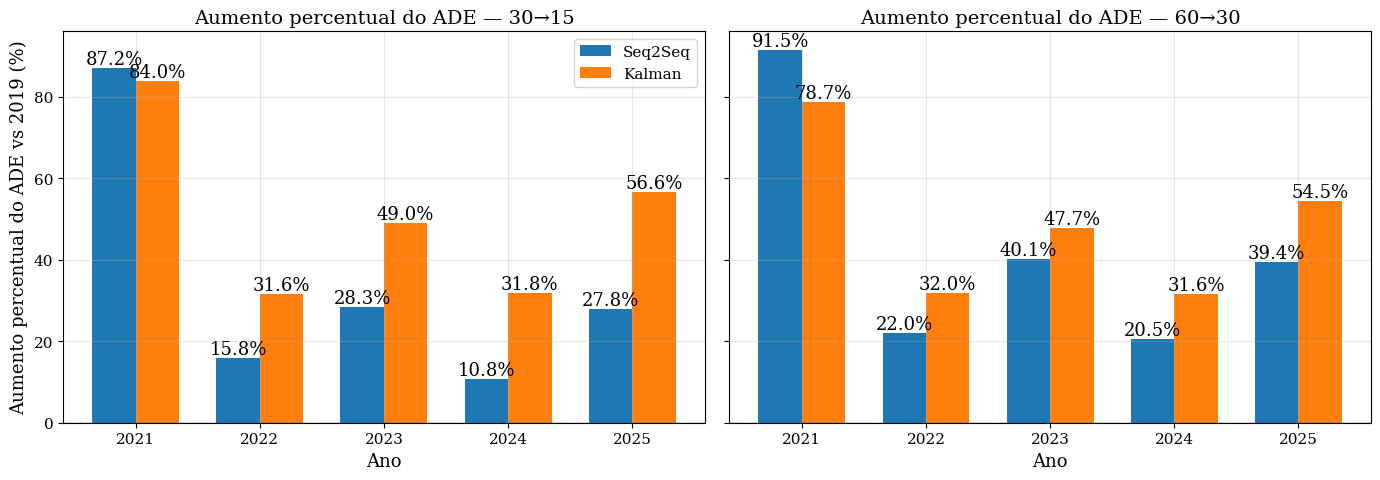

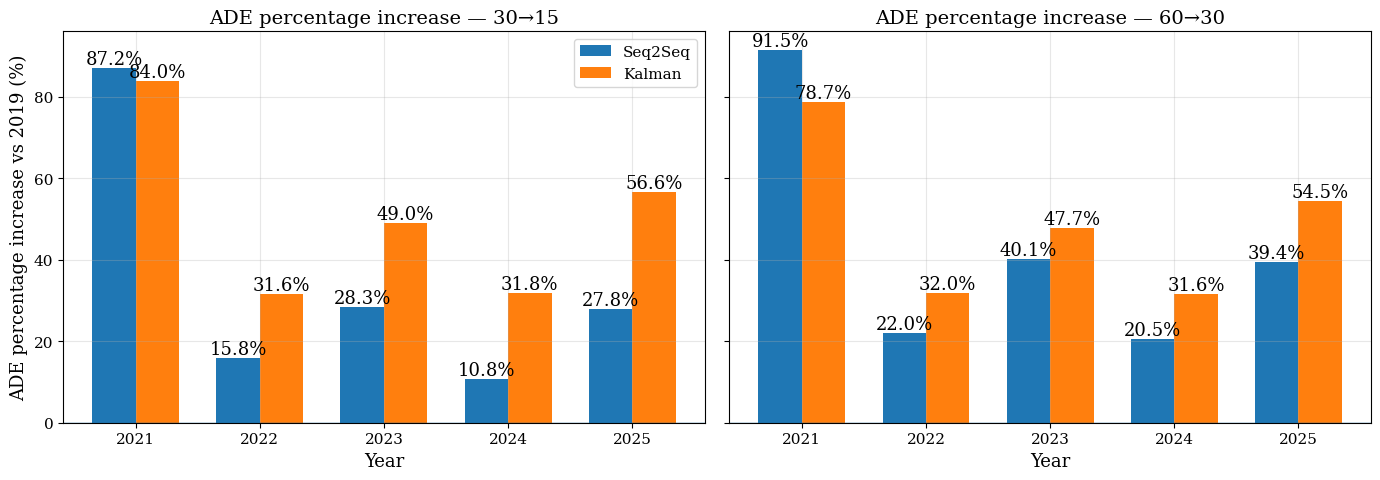

In [4]:
# =========================
# 1) Ler e preparar dados
# =========================
df = pd.read_csv("dataset.csv")

df_ade = df[
    (df["metric"] == "ADE") &
    (df["model"].isin(["Seq2Seq", "Kalman"]))
].copy()

df_ade = df_ade[~df_ade["year"].isin([2020])].copy()

df_ade["year"] = pd.to_numeric(df_ade["year"], errors="coerce")
df_ade["value"] = pd.to_numeric(df_ade["value"], errors="coerce")

g = (
    df_ade
    .groupby(["horizon", "model", "year"], as_index=False)["value"]
    .mean()
    .rename(columns={"value": "ade"})
)

baseline = (
    g[g["year"] == 2019][["horizon", "model", "ade"]]
    .rename(columns={"ade": "ade_2019"})
)

plot_df = g.merge(baseline, on=["horizon", "model"], how="left")
plot_df["pct_increase_vs_2019"] = 100 * (plot_df["ade"] / plot_df["ade_2019"] - 1)
plot_df = plot_df[plot_df["year"] != 2019].copy()


def make_plot_percade(lang):
    horizons = sorted(plot_df["horizon"].dropna().unique())
    fig, axes = plt.subplots(1, len(horizons), figsize=(7 * len(horizons), 5), sharey=True)
    if len(horizons) == 1:
        axes = [axes]

    for ax, horizon in zip(axes, horizons):
        d = plot_df[plot_df["horizon"] == horizon].copy()
        years = sorted(d["year"].dropna().unique())
        x = np.arange(len(years))
        width = 0.35

        seq = (d[d["model"] == "Seq2Seq"]
               .set_index("year").reindex(years)["pct_increase_vs_2019"])
        kal = (d[d["model"] == "Kalman"]
               .set_index("year").reindex(years)["pct_increase_vs_2019"])

        ax.bar(x - width/2, seq.values, width, label="Seq2Seq")
        ax.bar(x + width/2, kal.values, width, label="Kalman")
        ax.set_xticks(x)
        ax.set_xticklabels(years)
        ax.set_xlabel(T("Ano", "Year", lang))
        ax.set_title(T(f"Aumento percentual do ADE — {horizon}",
                       f"ADE percentage increase — {horizon}", lang))
        ax.axhline(0, linewidth=1)
        ax.grid(True, alpha=0.3)

        for xi, yi in zip(x - width/2, seq.values):
            if pd.notna(yi):
                ax.text(xi, yi, f"{yi:.1f}%", ha="center",
                        va="bottom" if yi >= 0 else "top")
        for xi, yi in zip(x + width/2, kal.values):
            if pd.notna(yi):
                ax.text(xi, yi, f"{yi:.1f}%", ha="center",
                        va="bottom" if yi >= 0 else "top")

    axes[0].set_ylabel(T("Aumento percentual do ADE vs 2019 (%)",
                         "ADE percentage increase vs 2019 (%)", lang))
    axes[0].legend()
    plt.tight_layout()
    plt.savefig(f"Relas/results/1.PercADE_{lang}.pdf", format="pdf", bbox_inches="tight")
    plt.show()


make_plot_percade("pt")
make_plot_percade("en")


In [5]:
def bootstrap_ci_mean(values, n_boot=2000, ci=95, seed=42):
    vals = np.asarray(values)
    vals = vals[np.isfinite(vals)]
    if vals.size == 0:
        return (np.nan, np.nan)
    rng = np.random.default_rng(seed)
    n = vals.size
    boot = np.empty(n_boot)
    for b in range(n_boot):
        boot[b] = np.mean(vals[rng.integers(0, n, size=n)])
    lo = np.percentile(boot, (100 - ci) / 2)
    hi = np.percentile(boot, 100 - (100 - ci) / 2)
    return lo, hi

def bootstrap_linreg_ci(x, y, x_grid=None, n_boot=2000, ci=95, seed=42):
    x = np.asarray(x); y = np.asarray(y)
    m = np.isfinite(x) & np.isfinite(y)
    x, y = x[m], y[m]
    if x.size < 3:
        return None
    if x_grid is None:
        x_grid = np.linspace(np.min(x), np.max(x), 120)
    rng = np.random.default_rng(seed)
    n = x.size
    yhat_grid = np.empty((n_boot, x_grid.size))
    for b in range(n_boot):
        idx = rng.integers(0, n, size=n)
        xb, yb = x[idx], y[idx]
        s, itc, _, _, _ = stats.linregress(xb, yb)
        yhat_grid[b] = s * x_grid + itc
    lo = np.percentile(yhat_grid, (100 - ci) / 2, axis=0)
    hi = np.percentile(yhat_grid, 100 - (100 - ci) / 2, axis=0)
    return {"x_grid": x_grid, "yhat_lo": lo, "yhat_hi": hi}

df_all_filtered = df_all[df_all["year"] != 2021].copy()

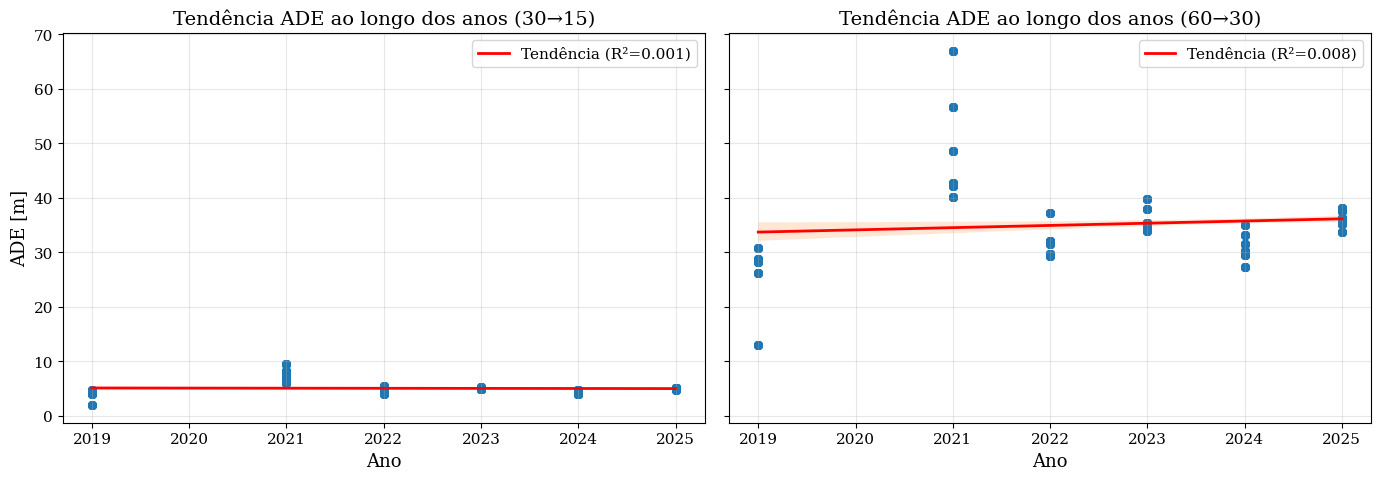

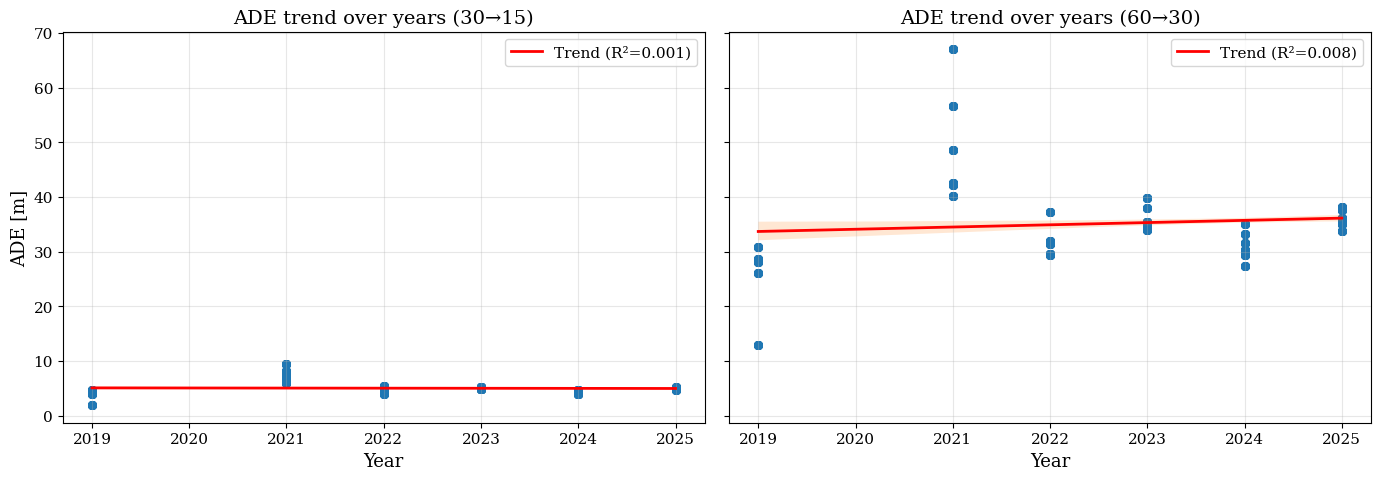

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats


def make_plot_adexyear(lang):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

    configs = [
        ("ade_30_15", "30→15"),
        ("ade_60_30", "60→30"),
    ]

    for ax, (col_ade, horizon_label) in zip(axes, configs):
        df_trend = df_all[["year", col_ade]].dropna().copy()

        x = df_trend["year"].values
        y = df_trend[col_ade].values

        slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)

        xg = np.linspace(df_trend["year"].min(), df_trend["year"].max(), 120)
        y_line = slope * xg + intercept

        boot_fit = bootstrap_linreg_ci(x, y, x_grid=xg)

        ax.scatter(x, y, alpha=0.5, s=30)
        ax.plot(
            xg, y_line, "r-", linewidth=2,
            label=T(f"Tendência (R²={r_value**2:.3f})",
                    f"Trend (R²={r_value**2:.3f})", lang),
        )

        if boot_fit is not None:
            ax.fill_between(boot_fit["x_grid"], boot_fit["yhat_lo"],
                            boot_fit["yhat_hi"], alpha=0.18)

        ax.set_xlabel(T("Ano", "Year", lang))
        ax.set_title(T(f"Tendência ADE ao longo dos anos ({horizon_label})",
                       f"ADE trend over years ({horizon_label})", lang))
        ax.legend()
        ax.grid(True, alpha=0.3)

    axes[0].set_ylabel("ADE [m]")
    plt.tight_layout()
    plt.savefig(f"Relas/results/2.ADExYear_{lang}.pdf", format="pdf", bbox_inches="tight")
    plt.show()


make_plot_adexyear("pt")
make_plot_adexyear("en")


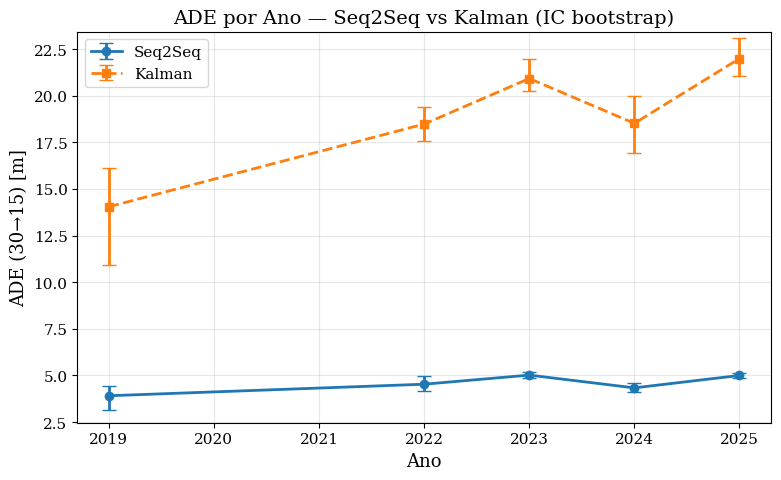

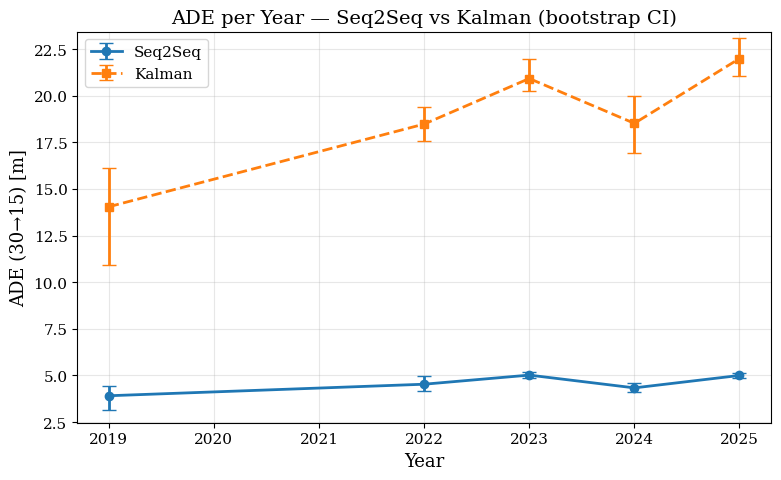

In [7]:
# ============================================================
# 8) ADE por Ano — Seq2Seq vs Kalman
# ============================================================
import numpy as np
import matplotlib.pyplot as plt


def make_plot_seq_vs_kalman(lang):
    fig, ax8 = plt.subplots(figsize=(8, 5))

    if "year" in df_all_filtered.columns:
        df_mod = df_all_filtered[
            (df_all_filtered["metric"] == "ADE") &
            (df_all_filtered["horizon"] == "30→15")
        ].copy()
    elif {"year", "model", "value", "metric", "horizon"}.issubset(df_all_filtered.columns):
        df_mod = df_all_filtered[
            (df_all_filtered["metric"] == "ADE") &
            (df_all_filtered["horizon"] == "30→15")
        ].copy()
    else:
        df_mod = None

    if df_mod is None:
        ax8.axis("off")
        ax8.set_title(T("Sem dados 'year' por modelo para plotar (Seq2Seq vs Kalman)",
                        "No 'year' data per model to plot (Seq2Seq vs Kalman)", lang))
    else:
        df_mod = df_mod[df_mod["model"].isin(["Seq2Seq", "Kalman"])].copy()
        years_plot = sorted(df_mod["year"].dropna().unique())

        seq_vals, seq_lo, seq_hi = [], [], []
        kal_vals, kal_lo, kal_hi = [], [], []

        for y in years_plot:
            seq_year = df_mod[(df_mod["year"] == y) & (df_mod["model"] == "Seq2Seq")]["value"].dropna().values
            kal_year = df_mod[(df_mod["year"] == y) & (df_mod["model"] == "Kalman")]["value"].dropna().values

            seq_vals.append(np.mean(seq_year) if seq_year.size else np.nan)
            kal_vals.append(np.mean(kal_year) if kal_year.size else np.nan)

            ls, hs = bootstrap_ci_mean(seq_year) if seq_year.size else (np.nan, np.nan)
            lk, hk = bootstrap_ci_mean(kal_year) if kal_year.size else (np.nan, np.nan)

            seq_lo.append(ls); seq_hi.append(hs)
            kal_lo.append(lk); kal_hi.append(hk)

        years_plot = np.array(years_plot)
        seq_vals = np.array(seq_vals); kal_vals = np.array(kal_vals)
        seq_lo = np.array(seq_lo); seq_hi = np.array(seq_hi)
        kal_lo = np.array(kal_lo); kal_hi = np.array(kal_hi)

        ax8.errorbar(years_plot, seq_vals,
                     yerr=[seq_vals - seq_lo, seq_hi - seq_vals],
                     marker="o", linestyle="-", label="Seq2Seq", capsize=5)
        ax8.errorbar(years_plot, kal_vals,
                     yerr=[kal_vals - kal_lo, kal_hi - kal_vals],
                     marker="s", linestyle="--", label="Kalman", capsize=5)

        all_vals = np.concatenate([seq_vals, kal_vals])
        all_vals = all_vals[np.isfinite(all_vals)]
        if all_vals.size:
            ymin, ymax = np.min(all_vals), np.max(all_vals)
            pad = (ymax - ymin) * 0.08 if ymax > ymin else 0.5
            ax8.set_ylim(ymin - pad, ymax + pad)

        ax8.set_title(T("ADE por Ano — Seq2Seq vs Kalman (IC bootstrap)",
                        "ADE per Year — Seq2Seq vs Kalman (bootstrap CI)", lang))
        ax8.set_xlabel(T("Ano", "Year", lang))
        ax8.set_ylabel("ADE (30→15) [m]")
        ax8.legend()
        ax8.grid(True, alpha=0.3, axis="y")

    plt.tight_layout()
    plt.savefig(f"Relas/results/3.Seq2seqVsKalman_{lang}.pdf", format="pdf", bbox_inches="tight")
    plt.show()


make_plot_seq_vs_kalman("pt")
make_plot_seq_vs_kalman("en")


C:\Users\ivang\AppData\Local\Temp\ipykernel_29596\4147588869.py:77: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax2.boxplot(data_fam, labels=fam_order, patch_artist=True, showfliers=False)
C:\Users\ivang\AppData\Local\Temp\ipykernel_29596\4147588869.py:346: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.savefig(f"Relas/results/4.PainelGeral_{lang}.pdf", format="pdf", bbox_inches="tight")
C:\Users\ivang\AppData\Local\Temp\ipykernel_29596\4147588869.py:346: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.savefig(f"Relas/results/4.PainelGeral_{lang}.pdf", format="pdf", bbox_inches="tight")
c:\Users\ivang\Desktop\trajectory-prediction\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: This figure includ

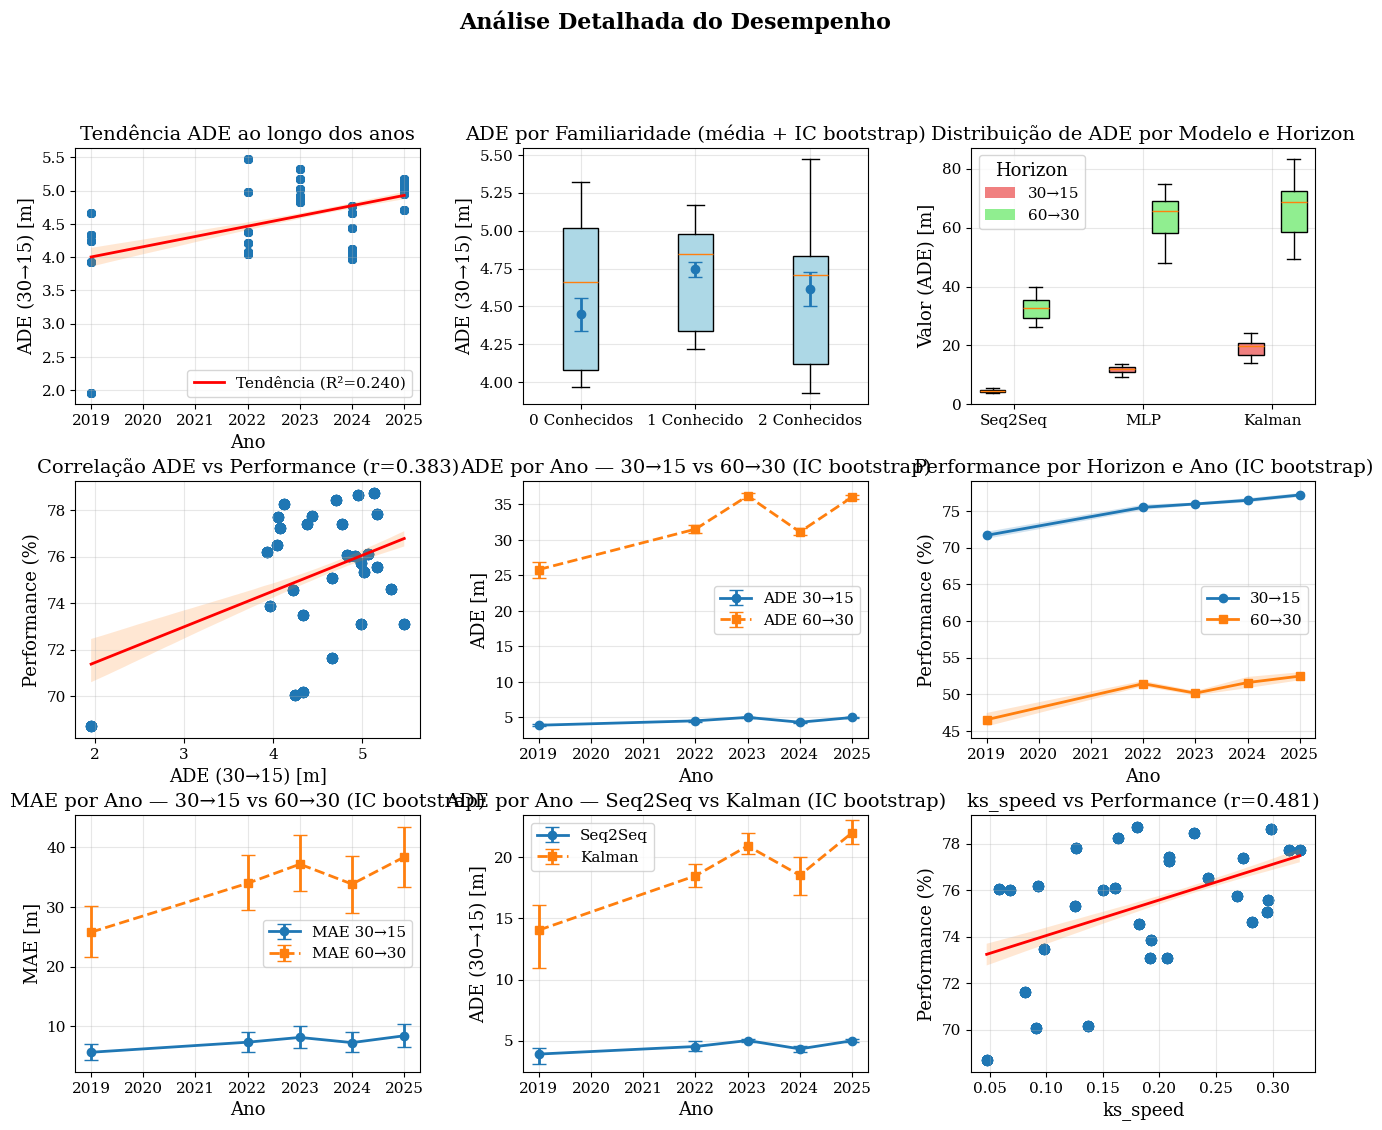

C:\Users\ivang\AppData\Local\Temp\ipykernel_29596\4147588869.py:77: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax2.boxplot(data_fam, labels=fam_order, patch_artist=True, showfliers=False)
C:\Users\ivang\AppData\Local\Temp\ipykernel_29596\4147588869.py:346: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.savefig(f"Relas/results/4.PainelGeral_{lang}.pdf", format="pdf", bbox_inches="tight")
C:\Users\ivang\AppData\Local\Temp\ipykernel_29596\4147588869.py:346: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.savefig(f"Relas/results/4.PainelGeral_{lang}.pdf", format="pdf", bbox_inches="tight")
c:\Users\ivang\Desktop\trajectory-prediction\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: This figure includ

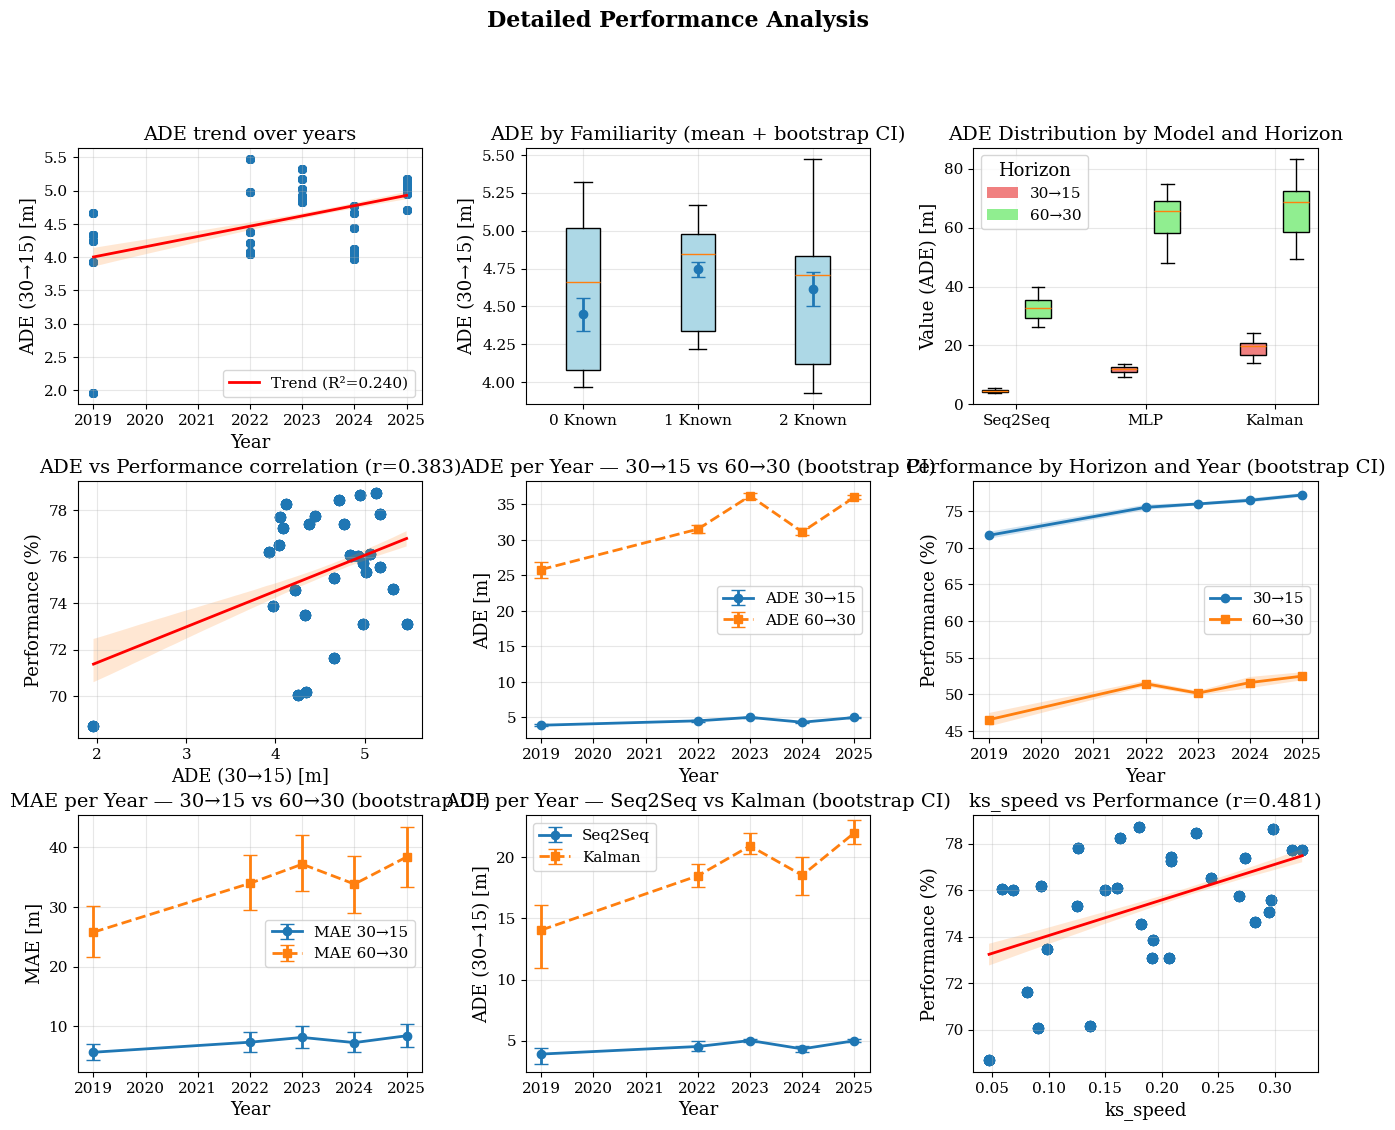

In [8]:
# ============================================================
# BOOTSTRAP HELPERS
# ============================================================
def bootstrap_ci_mean(values, n_boot=2000, ci=95, seed=42):
    vals = np.asarray(values)
    vals = vals[np.isfinite(vals)]
    if vals.size == 0:
        return (np.nan, np.nan)
    rng = np.random.default_rng(seed)
    n = vals.size
    boot = np.empty(n_boot)
    for b in range(n_boot):
        boot[b] = np.mean(vals[rng.integers(0, n, size=n)])
    lo = np.percentile(boot, (100 - ci) / 2)
    hi = np.percentile(boot, 100 - (100 - ci) / 2)
    return lo, hi

def bootstrap_linreg_ci(x, y, x_grid=None, n_boot=2000, ci=95, seed=42):
    x = np.asarray(x); y = np.asarray(y)
    m = np.isfinite(x) & np.isfinite(y)
    x, y = x[m], y[m]
    if x.size < 3:
        return None
    if x_grid is None:
        x_grid = np.linspace(np.min(x), np.max(x), 120)

    rng = np.random.default_rng(seed)
    n = x.size
    yhat_grid = np.empty((n_boot, x_grid.size))

    for b in range(n_boot):
        idx = rng.integers(0, n, size=n)
        xb, yb = x[idx], y[idx]
        s, itc, _, _, _ = stats.linregress(xb, yb)
        yhat_grid[b] = s * x_grid + itc

    lo = np.percentile(yhat_grid, (100 - ci) / 2, axis=0)
    hi = np.percentile(yhat_grid, 100 - (100 - ci) / 2, axis=0)
    return {"x_grid": x_grid, "yhat_lo": lo, "yhat_hi": hi}


df_all_filtered = df_all[df_all["year"] != 2021].copy()


def make_plot_painel(lang):
    fig = plt.figure(figsize=(16, 12))
    gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

    # 1) Tendência ADE ao longo dos anos
    ax1 = fig.add_subplot(gs[0, 0])
    df_trend = df_all_filtered[["year", "ade_30_15"]].dropna()
    slope, intercept, r_value, p_value, std_err = stats.linregress(df_trend["year"], df_trend["ade_30_15"])
    xg = np.linspace(df_trend["year"].min(), df_trend["year"].max(), 120)
    y_line = slope * xg + intercept
    boot_fit1 = bootstrap_linreg_ci(df_trend["year"].values, df_trend["ade_30_15"].values, x_grid=xg)

    ax1.scatter(df_trend["year"], df_trend["ade_30_15"], alpha=0.5, s=30)
    ax1.plot(xg, y_line, "r-", linewidth=2,
             label=T(f"Tendência (R²={r_value**2:.3f})",
                     f"Trend (R²={r_value**2:.3f})", lang))
    if boot_fit1 is not None:
        ax1.fill_between(boot_fit1["x_grid"], boot_fit1["yhat_lo"], boot_fit1["yhat_hi"], alpha=0.18)
    ax1.set_xlabel(T("Ano", "Year", lang))
    ax1.set_ylabel("ADE (30→15) [m]")
    ax1.set_title(T("Tendência ADE ao longo dos anos", "ADE trend over years", lang))
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # 2) ADE por familiaridade
    ax2 = fig.add_subplot(gs[0, 1])
    df_fam = df_all_filtered[["description", "ade_30_15"]].dropna()
    fam_order_pt = ["0 Conhecidos", "1 Conhecido", "2 Conhecidos"]
    fam_order_en = ["0 Known", "1 Known", "2 Known"]
    fam_order = fam_order_en if lang == "en" else fam_order_pt
    data_fam = [df_fam[df_fam["description"] == d]["ade_30_15"].values for d in fam_order_pt]

    bp = ax2.boxplot(data_fam, labels=fam_order, patch_artist=True, showfliers=False)
    for patch in bp["boxes"]:
        patch.set_facecolor("lightblue")

    means = np.array([np.mean(v) if len(v) else np.nan for v in data_fam])
    cis = [bootstrap_ci_mean(v) if len(v) else (np.nan, np.nan) for v in data_fam]
    lo = np.array([c[0] for c in cis]); hi = np.array([c[1] for c in cis])
    xpos = np.arange(1, len(fam_order) + 1)

    ax2.errorbar(xpos, means, yerr=[means - lo, hi - means], fmt="o", capsize=5, linewidth=2)
    ax2.set_ylabel("ADE (30→15) [m]")
    ax2.set_title(T("ADE por Familiaridade (média + IC bootstrap)",
                    "ADE by Familiarity (mean + bootstrap CI)", lang))
    ax2.grid(True, alpha=0.3, axis="y")

    # 3) Distribuição ADE por modelo e horizon
    ax3 = fig.add_subplot(gs[0, 2])
    df_mod_all = df_all_filtered[df_all_filtered["metric"] == "ADE"].copy()
    models = ["Seq2Seq", "MLP", "Kalman"]
    horizons_loc = ["30→15", "60→30"]

    data_to_plot = []
    positions = []
    for i, m in enumerate(models):
        for j, h in enumerate(horizons_loc):
            vals = df_mod_all[(df_mod_all["model"] == m) & (df_mod_all["horizon"] == h)]["value"].dropna().values
            data_to_plot.append(vals)
            positions.append(i * (len(horizons_loc) + 1) + j)

    bp2 = ax3.boxplot(data_to_plot, positions=positions, widths=0.6, patch_artist=True, showfliers=False)
    colors = ["lightcoral", "lightgreen"] * len(models)
    for patch, color in zip(bp2["boxes"], colors):
        patch.set_facecolor(color)

    xticks = [i * (len(horizons_loc) + 1) + 0.5 for i in range(len(models))]
    ax3.set_xticks(xticks)
    ax3.set_xticklabels(models)
    ax3.set_ylabel(T("Valor (ADE) [m]", "Value (ADE) [m]", lang))
    ax3.set_title(T("Distribuição de ADE por Modelo e Horizon",
                    "ADE Distribution by Model and Horizon", lang))
    ax3.legend([Patch(facecolor="lightcoral"), Patch(facecolor="lightgreen")],
               horizons_loc, title="Horizon")
    ax3.grid(True, alpha=0.3, axis="y")

    # 4) Correlação ADE vs Performance
    ax4 = fig.add_subplot(gs[1, 0])
    df_corr = df_all_filtered[["ade_30_15", "perf_30_15_pct"]].dropna()

    ax4.scatter(df_corr["ade_30_15"], df_corr["perf_30_15_pct"], alpha=0.6, s=50)
    z = np.polyfit(df_corr["ade_30_15"], df_corr["perf_30_15_pct"], 1)
    p = np.poly1d(z)
    xg = np.linspace(df_corr["ade_30_15"].min(), df_corr["ade_30_15"].max(), 120)
    ax4.plot(xg, p(xg), "r-", linewidth=2)

    boot_fit4 = bootstrap_linreg_ci(df_corr["ade_30_15"].values, df_corr["perf_30_15_pct"].values, x_grid=xg)
    if boot_fit4 is not None:
        ax4.fill_between(boot_fit4["x_grid"], boot_fit4["yhat_lo"], boot_fit4["yhat_hi"], alpha=0.18)

    corr_coef = df_corr["ade_30_15"].corr(df_corr["perf_30_15_pct"])
    ax4.set_xlabel("ADE (30→15) [m]")
    ax4.set_ylabel("Performance (%)")
    ax4.set_title(T(f"Correlação ADE vs Performance (r={corr_coef:.3f})",
                    f"ADE vs Performance correlation (r={corr_coef:.3f})", lang))
    ax4.grid(True, alpha=0.3)

    # 5) ADE por ano: 30→15 vs 60→30
    ax5 = fig.add_subplot(gs[1, 1])
    years_ = sorted(df_all_filtered["year"].dropna().unique())
    years_arr = np.array(years_)

    means_ade30, means_ade60 = [], []
    lo30, hi30, lo60, hi60 = [], [], [], []

    for y in years_:
        v30 = df_all_filtered.loc[df_all_filtered["year"] == y, "ade_30_15"].dropna().values
        v60 = df_all_filtered.loc[df_all_filtered["year"] == y, "ade_60_30"].dropna().values

        means_ade30.append(np.mean(v30) if v30.size else np.nan)
        means_ade60.append(np.mean(v60) if v60.size else np.nan)

        l30, h30 = bootstrap_ci_mean(v30) if v30.size else (np.nan, np.nan)
        l60, h60 = bootstrap_ci_mean(v60) if v60.size else (np.nan, np.nan)
        lo30.append(l30); hi30.append(h30); lo60.append(l60); hi60.append(h60)

    means_ade30 = np.array(means_ade30); means_ade60 = np.array(means_ade60)
    lo30 = np.array(lo30); hi30 = np.array(hi30)
    lo60 = np.array(lo60); hi60 = np.array(hi60)

    ax5.errorbar(years_arr, means_ade30, yerr=[means_ade30 - lo30, hi30 - means_ade30],
                 marker="o", linestyle="-", label="ADE 30→15", capsize=5)
    ax5.errorbar(years_arr, means_ade60, yerr=[means_ade60 - lo60, hi60 - means_ade60],
                 marker="s", linestyle="--", label="ADE 60→30", capsize=5)
    ax5.set_xlabel(T("Ano", "Year", lang))
    ax5.set_ylabel("ADE [m]")
    ax5.set_title(T("ADE por Ano — 30→15 vs 60→30 (IC bootstrap)",
                    "ADE per Year — 30→15 vs 60→30 (bootstrap CI)", lang))
    ax5.legend()
    ax5.grid(True, alpha=0.3)

    # 6) Performance por ano
    ax6 = fig.add_subplot(gs[1, 2])
    years = np.array(sorted(df_all_filtered["year"].dropna().unique()))

    means30, lo30p, hi30p = [], [], []
    means60, lo60p, hi60p = [], [], []

    for y in years:
        v30 = df_all_filtered.loc[df_all_filtered["year"] == y, "perf_30_15_pct"].dropna().values
        v60 = df_all_filtered.loc[df_all_filtered["year"] == y, "perf_60_30_pct"].dropna().values

        means30.append(np.mean(v30) if v30.size else np.nan)
        means60.append(np.mean(v60) if v60.size else np.nan)

        l30, h30 = bootstrap_ci_mean(v30) if v30.size else (np.nan, np.nan)
        l60, h60 = bootstrap_ci_mean(v60) if v60.size else (np.nan, np.nan)
        lo30p.append(l30); hi30p.append(h30); lo60p.append(l60); hi60p.append(h60)

    means30 = np.array(means30); means60 = np.array(means60)
    lo30p = np.array(lo30p); hi30p = np.array(hi30p)
    lo60p = np.array(lo60p); hi60p = np.array(hi60p)

    ax6.plot(years, means30, marker="o", label="30→15", linewidth=2)
    ax6.fill_between(years, lo30p, hi30p, alpha=0.2)
    ax6.plot(years, means60, marker="s", label="60→30", linewidth=2)
    ax6.fill_between(years, lo60p, hi60p, alpha=0.2)
    ax6.set_xlabel(T("Ano", "Year", lang))
    ax6.set_ylabel("Performance (%)")
    ax6.set_title(T("Performance por Horizon e Ano (IC bootstrap)",
                    "Performance by Horizon and Year (bootstrap CI)", lang))
    ax6.legend()
    ax6.grid(True, alpha=0.3)

    # 7) MAE por ano
    ax7 = fig.add_subplot(gs[2, 0])
    df_mae = df_all_filtered[df_all_filtered["metric"] == "MAE"].copy()

    means_mae30, means_mae60 = [], []
    lomae30, himae30, lomae60, himae60 = [], [], [], []

    for y in years_:
        v30 = df_mae.loc[(df_mae["year"] == y) & (df_mae["horizon"] == "30→15"), "value"].dropna().values
        v60 = df_mae.loc[(df_mae["year"] == y) & (df_mae["horizon"] == "60→30"), "value"].dropna().values

        means_mae30.append(np.mean(v30) if v30.size else np.nan)
        means_mae60.append(np.mean(v60) if v60.size else np.nan)

        l30, h30 = bootstrap_ci_mean(v30) if v30.size else (np.nan, np.nan)
        l60, h60 = bootstrap_ci_mean(v60) if v60.size else (np.nan, np.nan)
        lomae30.append(l30); himae30.append(h30); lomae60.append(l60); himae60.append(h60)

    means_mae30 = np.array(means_mae30); means_mae60 = np.array(means_mae60)
    lomae30 = np.array(lomae30); himae30 = np.array(himae30)
    lomae60 = np.array(lomae60); himae60 = np.array(himae60)

    ax7.errorbar(years_arr, means_mae30, yerr=[means_mae30 - lomae30, himae30 - means_mae30],
                 marker="o", linestyle="-", label="MAE 30→15", capsize=5)
    ax7.errorbar(years_arr, means_mae60, yerr=[means_mae60 - lomae60, himae60 - means_mae60],
                 marker="s", linestyle="--", label="MAE 60→30", capsize=5)
    ax7.set_xlabel(T("Ano", "Year", lang))
    ax7.set_ylabel("MAE [m]")
    ax7.set_title(T("MAE por Ano — 30→15 vs 60→30 (IC bootstrap)",
                    "MAE per Year — 30→15 vs 60→30 (bootstrap CI)", lang))
    ax7.legend()
    ax7.grid(True, alpha=0.3)

    # 8) ADE por Ano — Seq2Seq vs Kalman
    ax8 = fig.add_subplot(gs[2, 1])

    if "year" in df_all_filtered.columns:
        df_mod = df_all_filtered[(df_all_filtered["metric"] == "ADE") & (df_all_filtered["horizon"] == "30→15")].copy()
    elif {"year", "model", "value", "metric", "horizon"}.issubset(df_all_filtered.columns):
        df_mod = df_all_filtered[(df_all_filtered["metric"] == "ADE") & (df_all_filtered["horizon"] == "30→15")].copy()
    else:
        df_mod = None

    if df_mod is None:
        ax8.axis("off")
        ax8.set_title(T("Sem dados 'year' por modelo para plotar (Seq2Seq vs Kalman)",
                        "No 'year' data per model to plot (Seq2Seq vs Kalman)", lang))
    else:
        df_mod = df_mod[df_mod["model"].isin(["Seq2Seq", "Kalman"])].copy()
        years_plot = sorted(df_mod["year"].dropna().unique())

        seq_vals, seq_lo, seq_hi = [], [], []
        kal_vals, kal_lo, kal_hi = [], [], []

        for y in years_plot:
            seq_year = df_mod[(df_mod["year"] == y) & (df_mod["model"] == "Seq2Seq")]["value"].dropna().values
            kal_year = df_mod[(df_mod["year"] == y) & (df_mod["model"] == "Kalman")]["value"].dropna().values

            seq_vals.append(np.mean(seq_year) if seq_year.size else np.nan)
            kal_vals.append(np.mean(kal_year) if kal_year.size else np.nan)

            ls, hs = bootstrap_ci_mean(seq_year) if seq_year.size else (np.nan, np.nan)
            lk, hk = bootstrap_ci_mean(kal_year) if kal_year.size else (np.nan, np.nan)
            seq_lo.append(ls); seq_hi.append(hs); kal_lo.append(lk); kal_hi.append(hk)

        years_plot = np.array(years_plot)
        seq_vals = np.array(seq_vals); kal_vals = np.array(kal_vals)
        seq_lo = np.array(seq_lo); seq_hi = np.array(seq_hi)
        kal_lo = np.array(kal_lo); kal_hi = np.array(kal_hi)

        ax8.errorbar(years_plot, seq_vals, yerr=[seq_vals - seq_lo, seq_hi - seq_vals],
                     marker="o", linestyle="-", label="Seq2Seq", capsize=5)
        ax8.errorbar(years_plot, kal_vals, yerr=[kal_vals - kal_lo, kal_hi - kal_vals],
                     marker="s", linestyle="--", label="Kalman", capsize=5)

        all_vals = np.concatenate([seq_vals, kal_vals])
        all_vals = all_vals[np.isfinite(all_vals)]
        if all_vals.size:
            ymin, ymax = np.min(all_vals), np.max(all_vals)
            pad = (ymax - ymin) * 0.08 if ymax > ymin else 0.5
            ax8.set_ylim(ymin - pad, ymax + pad)

        ax8.set_title(T("ADE por Ano — Seq2Seq vs Kalman (IC bootstrap)",
                        "ADE per Year — Seq2Seq vs Kalman (bootstrap CI)", lang))
        ax8.set_xlabel(T("Ano", "Year", lang))
        ax8.set_ylabel("ADE (30→15) [m]")
        ax8.legend()
        ax8.grid(True, alpha=0.3, axis="y")

    # 9) KS Speed vs Performance
    ax9 = fig.add_subplot(gs[2, 2])

    perf_col = "perf_30_15_pct"
    if perf_col not in df_all_filtered.columns:
        ax9.axis("off")
        ax9.set_title(T(f"Sem coluna '{perf_col}' para plotar",
                        f"Missing column '{perf_col}' to plot", lang))
    else:
        ks_candidates = [
            "ks_speed", "ks_speed_p99", "ks_speed_mean",
            "ks_v", "ks_vel", "ks_velocity", "ks_speed_stat",
            "ks_speed_30_15", "ks_speed_60_30", "ks",
        ]
        ks_col = next((c for c in ks_candidates if c in df_all_filtered.columns), None)

        if ks_col is None:
            ax9.axis("off")
            ax9.set_title(T("Sem coluna KS Speed (ks_speed) ou equivalente",
                            "Missing KS Speed column (ks_speed) or equivalent", lang))
        else:
            df_ks = df_all_filtered[[ks_col, perf_col]].dropna()
            if len(df_ks) < 3:
                ax9.axis("off")
                ax9.set_title(T("Poucos pontos para KS vs Performance",
                                "Too few points for KS vs Performance", lang))
            else:
                ax9.scatter(df_ks[ks_col], df_ks[perf_col], alpha=0.6, s=50)
                corr_ks = df_ks[ks_col].corr(df_ks[perf_col])

                z = np.polyfit(df_ks[ks_col], df_ks[perf_col], 1)
                p = np.poly1d(z)
                xg = np.linspace(df_ks[ks_col].min(), df_ks[ks_col].max(), 120)
                ax9.plot(xg, p(xg), "r-", linewidth=2)

                boot_fit9 = bootstrap_linreg_ci(df_ks[ks_col].values, df_ks[perf_col].values, x_grid=xg)
                if boot_fit9 is not None:
                    ax9.fill_between(boot_fit9["x_grid"], boot_fit9["yhat_lo"], boot_fit9["yhat_hi"], alpha=0.18)

                ax9.set_xlabel(ks_col)
                ax9.set_ylabel("Performance (%)")
                ax9.set_title(T(f"{ks_col} vs Performance (r={corr_ks:.3f})",
                                f"{ks_col} vs Performance (r={corr_ks:.3f})", lang))
                ax9.grid(True, alpha=0.3)

    plt.suptitle(T("Análise Detalhada do Desempenho",
                   "Detailed Performance Analysis", lang),
                 fontsize=16, fontweight="bold", y=0.995)
    plt.savefig(f"Relas/results/4.PainelGeral_{lang}.pdf", format="pdf", bbox_inches="tight")
    plt.show()


make_plot_painel("pt")
make_plot_painel("en")


# Komolgorov Smirnov e Wasserstein

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# -----------------------------
# Bootstrap CI (para média ou estatística custom)
# -----------------------------
def bootstrap_ci(
    x,
    statistic=np.mean,
    n_boot=2000,
    ci=95,
    random_state=0,
):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    if x.size == 0:
        return (np.nan, np.nan)

    rng = np.random.default_rng(random_state)
    n = x.size
    idx = rng.integers(0, n, size=(n_boot, n))
    boots = statistic(x[idx], axis=1)

    alpha = (100 - ci) / 2
    lo = np.percentile(boots, alpha)
    hi = np.percentile(boots, 100 - alpha)
    return float(lo), float(hi)


# -----------------------------
# 1) Plot: Δmetric vs baseline com IC (df_drift já vem com ci_low/ci_high)
# -----------------------------
def plot_drift_ci_per_metric(
    df_drift,
    baseline_year=2019,
    metrics=("ADE", "FDE", "MAE"),
    horizons=("30→15", "60→30"),
    figsize=(8.5, 4.6),
    capsize=4,
    linewidth=2,
    marker="o",
):
    req = ["metric", "horizon", "year", "obs_delta_vs_2019", "ci_low", "ci_high"]
    missing = [c for c in req if c not in df_drift.columns]
    if missing:
        raise ValueError(f"df_drift missing columns: {missing}")

    d = df_drift.copy()
    d["year"] = pd.to_numeric(d["year"], errors="coerce")

    for metric in metrics:
        fig, ax = plt.subplots(figsize=figsize)
        ax.axhline(0, linewidth=1)

        any_plot = False
        for horizon in horizons:
            g = d[(d["metric"] == metric) & (d["horizon"] == horizon)].copy()
            if g.empty:
                continue

            g = g.sort_values("year")
            x = g["year"].to_numpy()
            y = g["obs_delta_vs_2019"].to_numpy()
            lo = g["ci_low"].to_numpy()
            hi = g["ci_high"].to_numpy()

            ok = np.isfinite(x) & np.isfinite(y) & np.isfinite(lo) & np.isfinite(hi)
            x, y, lo, hi = x[ok], y[ok], lo[ok], hi[ok]
            if x.size == 0:
                continue

            any_plot = True
            yerr = np.vstack([y - lo, hi - y])

            ax.errorbar(
                x, y,
                yerr=yerr,
                fmt=f"{marker}-",
                capsize=capsize,
                linewidth=linewidth,
                markersize=6,
                label=horizon,
            )

        if not any_plot:
            plt.close(fig)
            continue

        years_all = d.loc[d["metric"] == metric, "year"].dropna().unique()
        if years_all.size:
            ax.set_xticks(np.sort(years_all.astype(int)))

        ax.set_title(f"{metric} drift vs {baseline_year} (IC95%)")
        ax.set_xlabel("Ano")
        ax.set_ylabel(f"Δ {metric} (ano − {baseline_year})")
        ax.grid(True, alpha=0.25)
        ax.legend(title="Horizon", frameon=False)
        fig.tight_layout()
        plt.show()


# -----------------------------
# 2) Agregar KS/WD por (year, feature) com IC bootstrap e plotar
# -----------------------------
def summarize_feature_ci(
    df_drift_feat,
    value_col,
    group_cols=("year", "feature"),
    n_boot=2000,
    ci=95,
    random_state=0,
):
    d = df_drift_feat.copy()
    d["year"] = pd.to_numeric(d["year"], errors="coerce")
    d[value_col] = pd.to_numeric(d[value_col], errors="coerce")

    out_rows = []
    grouped = d.groupby(list(group_cols), dropna=False)

    for keys, g in grouped:
        vals = g[value_col].dropna().to_numpy()
        mean = float(np.nanmean(vals)) if vals.size else np.nan
        lo, hi = bootstrap_ci(vals, n_boot=n_boot, ci=ci, random_state=random_state) if vals.size else (np.nan, np.nan)

        if not isinstance(keys, tuple):
            keys = (keys,)
        row = dict(zip(group_cols, keys))
        row.update({"mean": mean, "ci_low": lo, "ci_high": hi, "n": int(vals.size)})
        out_rows.append(row)

    return pd.DataFrame(out_rows)


def plot_feature_ci_over_years(
    df_drift_feat,
    value_cols=("ks", "wasserstein"),
    n_boot=2000,
    ci=95,
    random_state=0,
    figsize=(14, 5),
    marker="o",
):
    features = sorted(df_drift_feat["feature"].dropna().unique().tolist())
    years = np.sort(pd.to_numeric(df_drift_feat["year"], errors="coerce").dropna().unique()).astype(int)

    fig, axes = plt.subplots(1, len(value_cols), figsize=figsize, sharex=True)
    if len(value_cols) == 1:
        axes = [axes]

    for ax, col in zip(axes, value_cols):
        summ = summarize_feature_ci(
            df_drift_feat,
            value_col=col,
            n_boot=n_boot,
            ci=ci,
            random_state=random_state,
        )

        for feat in features:
            g = summ[summ["feature"] == feat].copy()
            g["year"] = g["year"].astype(int)
            g = g.set_index("year").reindex(years).reset_index()

            ax.plot(g["year"].to_numpy(), g["mean"].to_numpy(), marker=marker, label=feat)
            ax.fill_between(g["year"].to_numpy(), g["ci_low"].to_numpy(), g["ci_high"].to_numpy(), alpha=0.2)

        ax.set_title(f"{col.upper()} por ano (IC{ci}% via bootstrap)")
        ax.set_xlabel("Ano")
        ax.set_ylabel(col)
        ax.set_xticks(years)
        ax.grid(True, alpha=0.3)
        ax.legend(title="feature")

    plt.tight_layout()
    plt.show()


In [10]:
df_drift_feat = pd.read_csv("covariate_shift_out/ks_wd_per_dataset.csv")

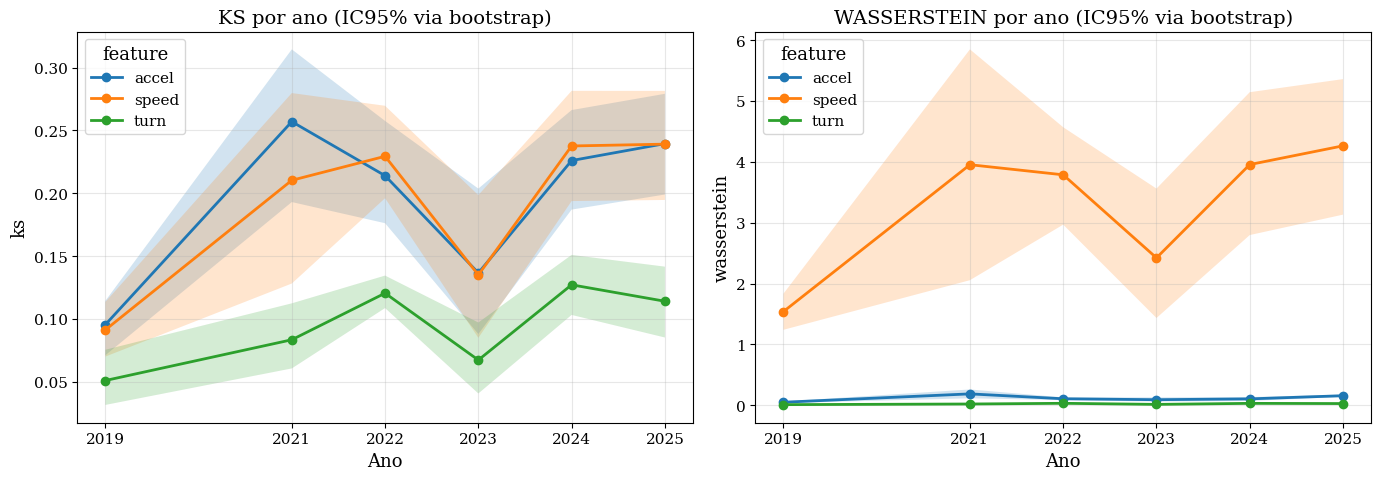

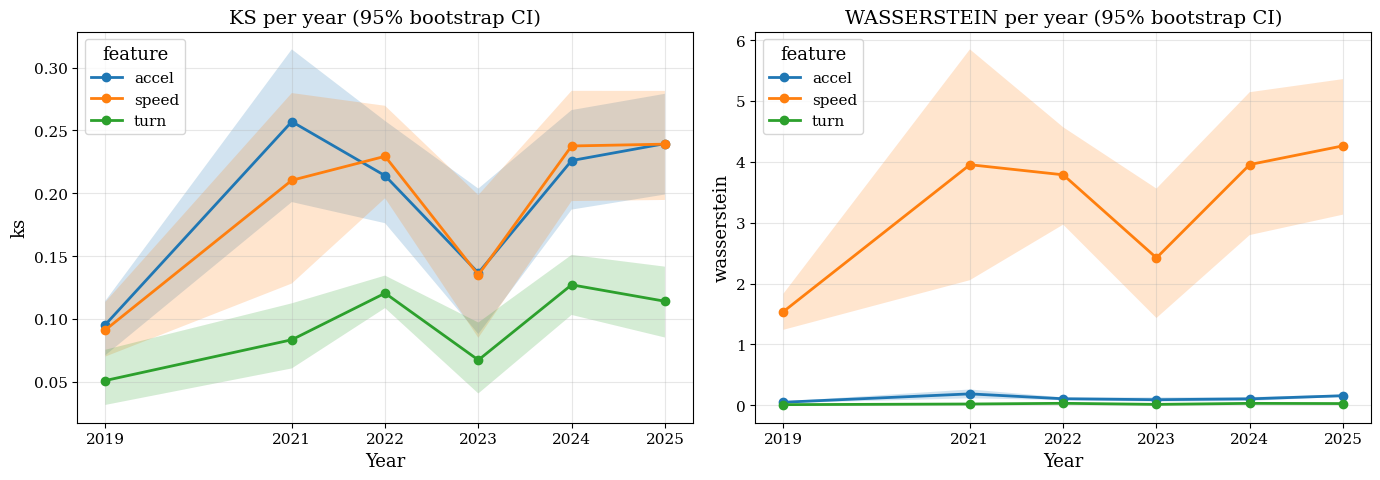

In [11]:
def make_plot_ks_wd_year(lang):
    features = sorted(df_drift_feat["feature"].dropna().unique())
    years = sorted(pd.to_numeric(df_drift_feat["year"], errors="coerce").dropna().unique().astype(int))

    fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True)

    for ax, col in zip(axes, ["ks", "wasserstein"]):
        for feat in features:
            means, lo, hi = [], [], []
            for y in years:
                vals = df_drift_feat.loc[
                    (df_drift_feat["year"].astype(int) == y) & (df_drift_feat["feature"] == feat),
                    col,
                ].dropna().to_numpy()

                if vals.size == 0:
                    means.append(np.nan); lo.append(np.nan); hi.append(np.nan)
                else:
                    means.append(vals.mean())
                    l, h = bootstrap_ci(vals, n_boot=2000, ci=95, random_state=0)
                    lo.append(l); hi.append(h)

            years_arr = np.array(years, dtype=int)
            means = np.array(means, dtype=float)
            lo = np.array(lo, dtype=float)
            hi = np.array(hi, dtype=float)

            ax.plot(years_arr, means, marker="o", label=feat)
            ax.fill_between(years_arr, lo, hi, alpha=0.2)

        ax.set_title(T(f"{col.upper()} por ano (IC95% via bootstrap)",
                       f"{col.upper()} per year (95% bootstrap CI)", lang))
        ax.set_xlabel(T("Ano", "Year", lang))
        ax.set_ylabel(col)
        ax.set_xticks(years)
        ax.grid(True, alpha=0.3)
        ax.legend(title="feature")

    plt.tight_layout()
    plt.savefig(f"Relas/results/5.KS_WD_xYear_{lang}.pdf", format="pdf", bbox_inches="tight")
    plt.show()


make_plot_ks_wd_year("pt")
make_plot_ks_wd_year("en")


Modelo explicativo (OLS) para 
    
    
ΔADE ~  ks_speed + 
            ks_accel + 
            ks_turn +
            C(year)


ΔADE∼   wd_speed +
        wd_accel +
        wd_turn +
        C(year)

desconsiderando 2021
- Como tudo cruza o zero entao nenhum ks é explicativo o suficiente 

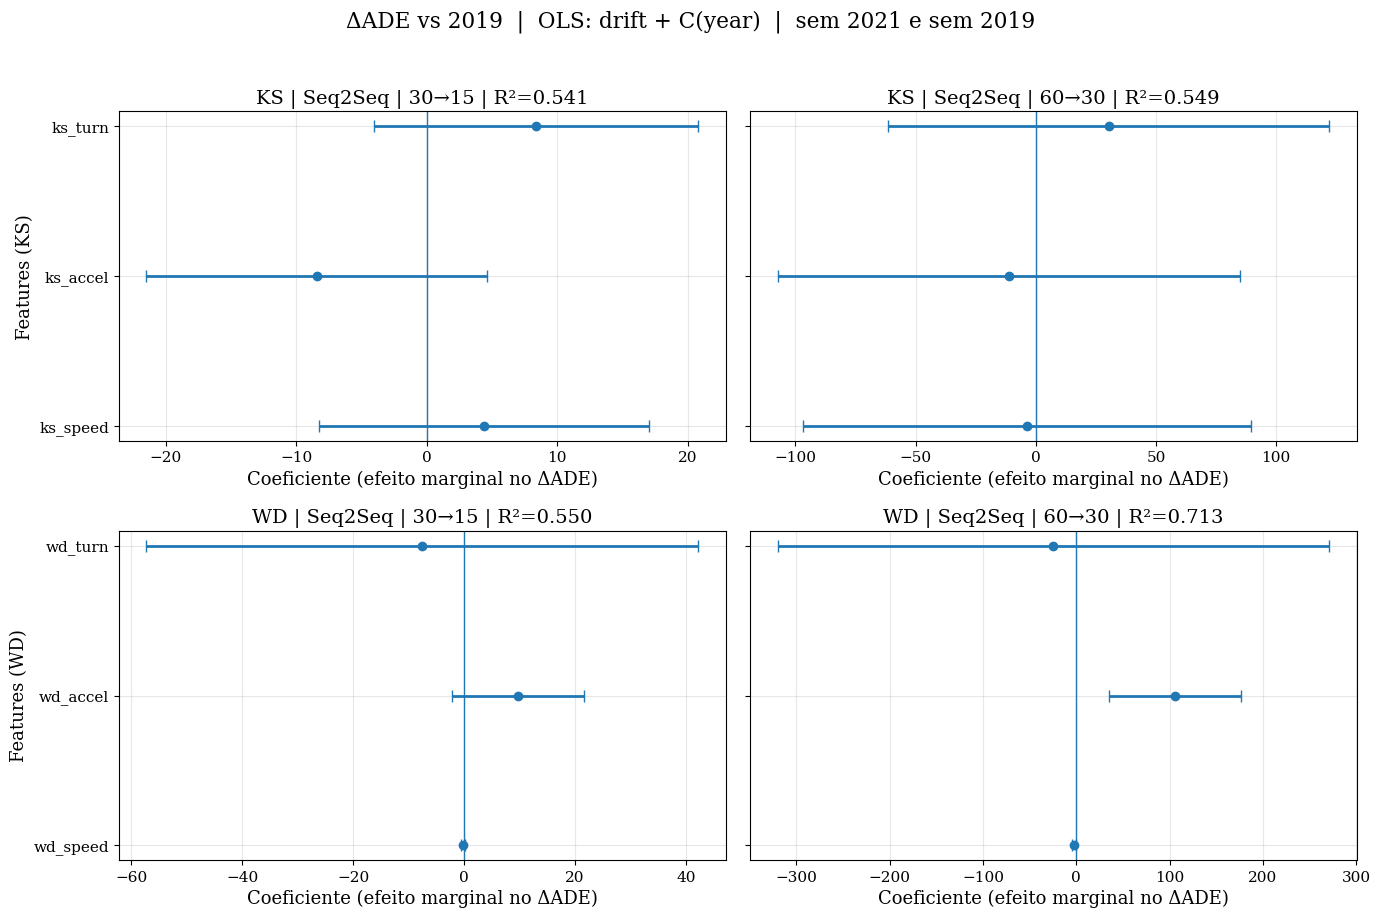

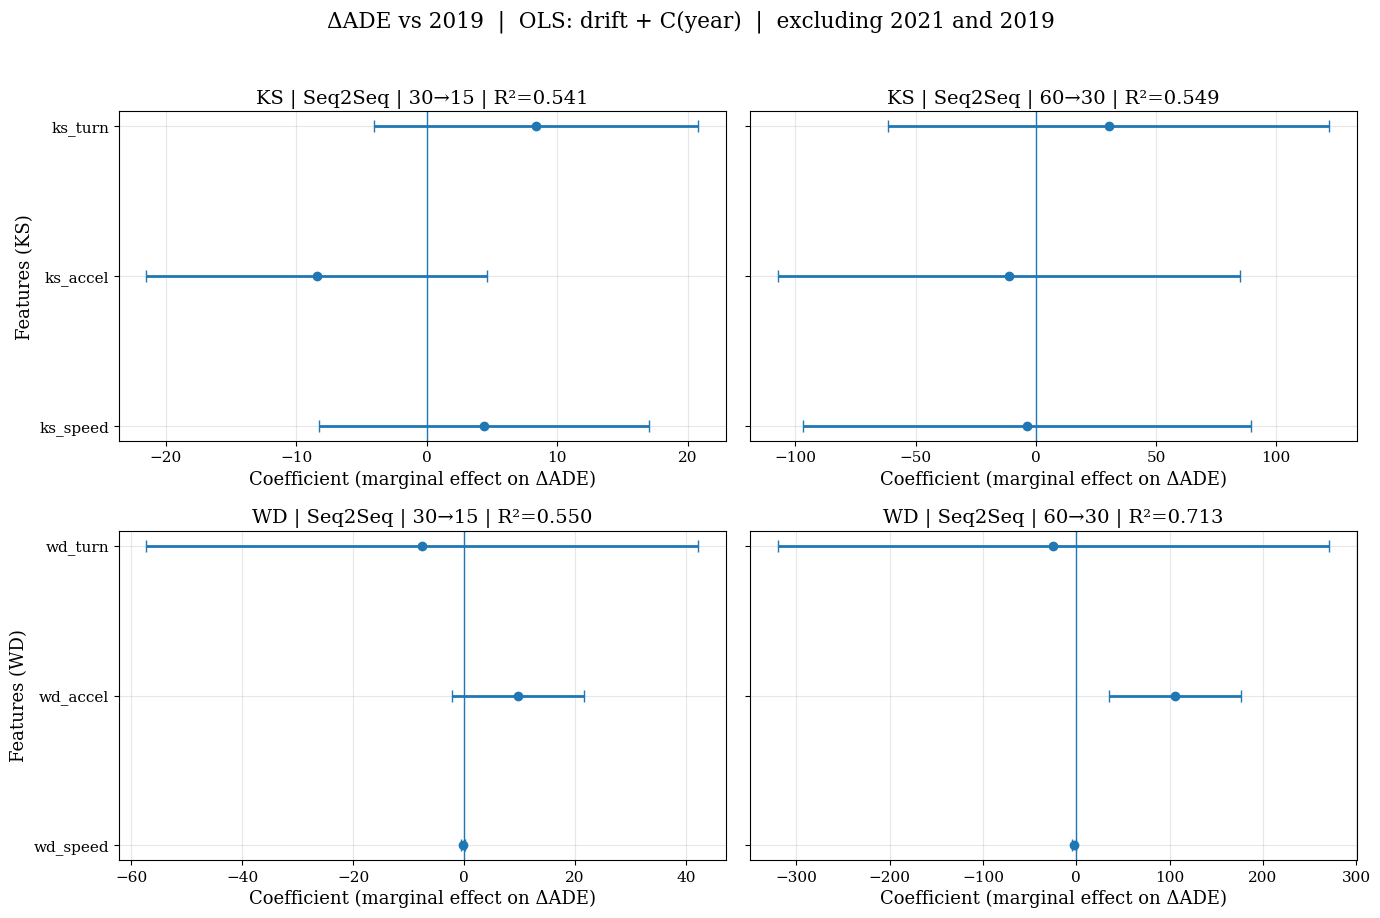

Resumo OLS (ΔADE ~ drift + C(year)) | type=KS ou WD


,type,horizon,n,r2,adj_r2,aic,bic
0,KS,30→15,24,0.540881,0.378839,24.074741,32.321118
1,KS,60→30,24,0.548584,0.389261,120.007781,128.254158
2,WD,30→15,24,0.550159,0.391392,23.584787,31.831164
3,WD,60→30,24,0.713050,0.611774,109.133815,117.380192


COEFICIENTES | TYPE=KS | MODEL=Seq2Seq | HORIZON=30→15 | FEATURES=['ks_speed', 'ks_accel', 'ks_turn'] | DROP_YEAR=2021 | BASELINE=2019


,feature,coef,p_value,ci_low,ci_high
0,ks_turn,8.352599,0.174250,-4.074735,20.779932
1,ks_accel,-8.418705,0.191196,-21.466607,4.629197
2,ks_speed,4.398136,0.472363,-8.226835,17.023107


COEFICIENTES | TYPE=WD | MODEL=Seq2Seq | HORIZON=30→15 | FEATURES=['wd_speed', 'wd_accel', 'wd_turn'] | DROP_YEAR=2021 | BASELINE=2019


,feature,coef,p_value,ci_low,ci_high
0,wd_accel,9.725804,0.102979,-2.181623,21.633230
1,wd_speed,-0.162294,0.335652,-0.507865,0.183277
2,wd_turn,-7.524501,0.753323,-57.229674,42.180673


COEFICIENTES | TYPE=KS | MODEL=Seq2Seq | HORIZON=60→30 | FEATURES=['ks_speed', 'ks_accel', 'ks_turn'] | DROP_YEAR=2021 | BASELINE=2019


,feature,coef,p_value,ci_low,ci_high
0,ks_turn,30.336761,0.494617,-61.361496,122.035019
1,ks_accel,-11.114774,0.810480,-107.392053,85.162506
2,ks_speed,-3.556234,0.936747,-96.712808,89.600341


COEFICIENTES | TYPE=WD | MODEL=Seq2Seq | HORIZON=60→30 | FEATURES=['wd_speed', 'wd_accel', 'wd_turn'] | DROP_YEAR=2021 | BASELINE=2019


,feature,coef,p_value,ci_low,ci_high
0,wd_accel,105.647135,0.005848,34.877240,176.417030
1,wd_speed,-2.301820,0.030213,-4.355668,-0.247972
2,wd_turn,-24.610831,0.862553,-320.025619,270.803957


In [12]:
BASELINE_YEAR = 2019
DROP_YEAR = 2021
MODEL = "Seq2Seq"
HORIZONS = ["30→15", "60→30"]

KS_COLS = ["ks_speed", "ks_accel", "ks_turn"]
WD_COLS = ["wd_speed", "wd_accel", "wd_turn"]

df = df_all.copy()
df = df[df["year"].ne(DROP_YEAR)].copy()
df = df[(df["model"] == MODEL) & (df["metric"] == "ADE")].copy()

df["year"] = pd.to_numeric(df["year"], errors="coerce")
df["dataset"] = pd.to_numeric(df["dataset"], errors="coerce")
df["value"] = pd.to_numeric(df["value"], errors="coerce")

for c in set(KS_COLS + WD_COLS):
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

baseline = (
    df[df["year"] == BASELINE_YEAR]
    .groupby("horizon")["value"].mean()
    .rename("baseline_2019").reset_index()
)
df = df.merge(baseline, on="horizon", how="left")
df["delta_ADE"] = df["value"] - df["baseline_2019"]
df = df.dropna(subset=["delta_ADE", "year", "horizon"]).copy()
df["year"] = df["year"].astype(int)
df = df[df["year"] != BASELINE_YEAR].copy()


def fit_ols(df_h, feat_cols):
    rhs = " + ".join(feat_cols) + " + C(year)"
    return smf.ols(f"delta_ADE ~ {rhs}", data=df_h).fit()

def coef_table(model, feat_cols):
    ci = model.conf_int()
    ci.columns = ["ci_low", "ci_high"]
    return pd.DataFrame({
        "feature": feat_cols,
        "coef": [model.params[c] for c in feat_cols],
        "p_value": [model.pvalues[c] for c in feat_cols],
        "ci_low": [ci.loc[c, "ci_low"] for c in feat_cols],
        "ci_high": [ci.loc[c, "ci_high"] for c in feat_cols],
    })

ks_present = [c for c in KS_COLS if c in df.columns]
wd_present = [c for c in WD_COLS if c in df.columns]

if len(ks_present) < 2:
    raise KeyError(f"Poucas colunas KS disponíveis. Encontrei: {ks_present}")
if len(wd_present) < 2:
    raise KeyError(f"Poucas colunas WD disponíveis. Encontrei: {wd_present}")


def make_plot_ols(lang):
    def plot_coef_panel(ax, ct, title):
        order = ct["feature"].tolist()
        y = np.arange(len(order))
        x = ct["coef"].to_numpy()
        lo = ct["ci_low"].to_numpy()
        hi = ct["ci_high"].to_numpy()
        xerr = np.vstack([x - lo, hi - x])

        ax.axvline(0, linewidth=1)
        ax.errorbar(x, y, xerr=xerr, fmt="o", capsize=4)
        ax.set_yticks(y)
        ax.set_yticklabels(order)
        ax.set_title(title)
        ax.grid(True, axis="x", alpha=0.3)
        ax.set_xlabel(T("Coeficiente (efeito marginal no ΔADE)",
                        "Coefficient (marginal effect on ΔADE)", lang))

    fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharey="row")
    axes = np.atleast_2d(axes)

    models = {"KS": {}, "WD": {}}
    coefs = {"KS": {}, "WD": {}}
    summ_rows = []

    for j, horizon in enumerate(HORIZONS):
        df_h = df[df["horizon"] == horizon].dropna(subset=ks_present + wd_present).copy()
        if df_h.empty:
            axes[0, j].axis("off")
            axes[1, j].axis("off")
            continue

        m_ks = fit_ols(df_h, ks_present)
        ct_ks = coef_table(m_ks, ks_present)
        models["KS"][horizon] = m_ks
        coefs["KS"][horizon] = ct_ks

        m_wd = fit_ols(df_h, wd_present)
        ct_wd = coef_table(m_wd, wd_present)
        models["WD"][horizon] = m_wd
        coefs["WD"][horizon] = ct_wd

        plot_coef_panel(axes[0, j], ct_ks,
                        title=f"KS | {MODEL} | {horizon} | R²={m_ks.rsquared:.3f}")
        plot_coef_panel(axes[1, j], ct_wd,
                        title=f"WD | {MODEL} | {horizon} | R²={m_wd.rsquared:.3f}")

        summ_rows += [
            {"type": "KS", "horizon": horizon, "n": int(m_ks.nobs),
             "r2": float(m_ks.rsquared), "adj_r2": float(m_ks.rsquared_adj),
             "aic": float(m_ks.aic), "bic": float(m_ks.bic)},
            {"type": "WD", "horizon": horizon, "n": int(m_wd.nobs),
             "r2": float(m_wd.rsquared), "adj_r2": float(m_wd.rsquared_adj),
             "aic": float(m_wd.aic), "bic": float(m_wd.bic)},
        ]

    axes[0, 0].set_ylabel("Features (KS)")
    axes[1, 0].set_ylabel("Features (WD)")
    fig.suptitle(T(f"ΔADE vs {BASELINE_YEAR}  |  OLS: drift + C(year)  |  sem {DROP_YEAR} e sem {BASELINE_YEAR}",
                   f"ΔADE vs {BASELINE_YEAR}  |  OLS: drift + C(year)  |  excluding {DROP_YEAR} and {BASELINE_YEAR}", lang),
                 y=1.02)
    fig.tight_layout()
    plt.savefig(f"Relas/results/6.OLS_KS_WD_{lang}.pdf", format="pdf", bbox_inches="tight")
    plt.show()
    return models, coefs, summ_rows


_models, coefs, summ_rows = make_plot_ols("pt")
make_plot_ols("en")

if summ_rows:
    summary_df = pd.DataFrame(summ_rows).sort_values(["type", "horizon"]).reset_index(drop=True)
    print("Resumo OLS (ΔADE ~ drift + C(year)) | type=KS ou WD")
    display(summary_df)

for horizon in HORIZONS:
    if horizon in coefs["KS"]:
        print(f"COEFICIENTES | TYPE=KS | MODEL={MODEL} | HORIZON={horizon} | FEATURES={ks_present} | DROP_YEAR={DROP_YEAR} | BASELINE={BASELINE_YEAR}")
        display(coefs["KS"][horizon].sort_values("p_value").reset_index(drop=True))

    if horizon in coefs["WD"]:
        print(f"COEFICIENTES | TYPE=WD | MODEL={MODEL} | HORIZON={horizon} | FEATURES={wd_present} | DROP_YEAR={DROP_YEAR} | BASELINE={BASELINE_YEAR}")
        display(coefs["WD"][horizon].sort_values("p_value").reset_index(drop=True))


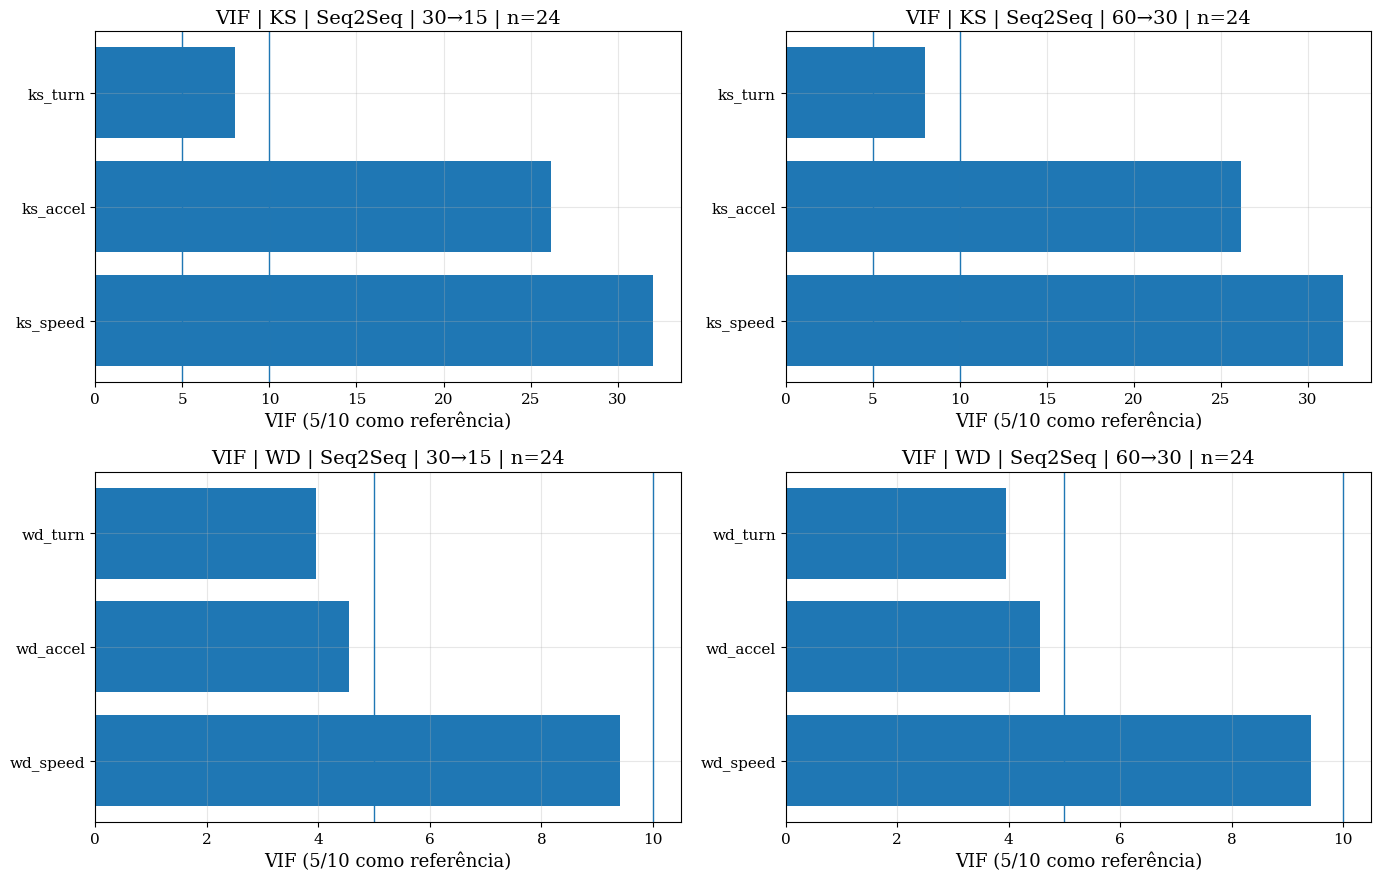

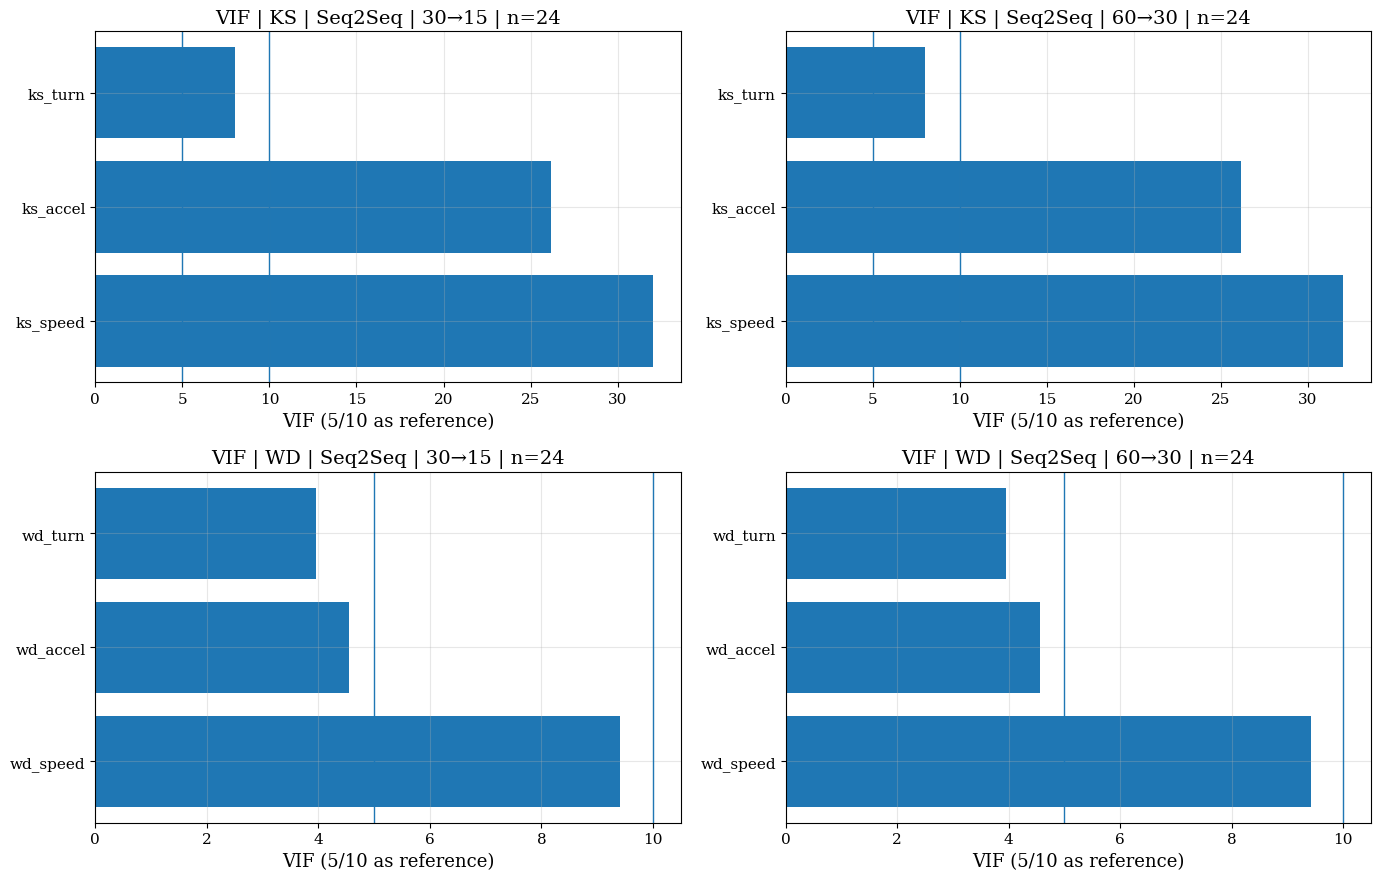

VIF TABLE | TYPE=KS | MODEL=Seq2Seq | HORIZON=30→15 | DROP_YEAR=2021 | BASELINE=2019


,feature,vif,n
0,ks_speed,32.024353,24
1,ks_accel,26.153723,24
2,ks_turn,8.031019,24


VIF TABLE | TYPE=WD | MODEL=Seq2Seq | HORIZON=30→15 | DROP_YEAR=2021 | BASELINE=2019


,feature,vif,n
0,wd_speed,9.419233,24
1,wd_accel,4.556126,24
2,wd_turn,3.958377,24


VIF TABLE | TYPE=KS | MODEL=Seq2Seq | HORIZON=60→30 | DROP_YEAR=2021 | BASELINE=2019


,feature,vif,n
0,ks_speed,32.024353,24
1,ks_accel,26.153723,24
2,ks_turn,8.031019,24


VIF TABLE | TYPE=WD | MODEL=Seq2Seq | HORIZON=60→30 | DROP_YEAR=2021 | BASELINE=2019


,feature,vif,n
0,wd_speed,9.419233,24
1,wd_accel,4.556126,24
2,wd_turn,3.958377,24


In [13]:
BASELINE_YEAR = 2019
DROP_YEAR = 2021
MODEL = "Seq2Seq"
METRIC = "ADE"
HORIZONS = ["30→15", "60→30"]

KS_COLS = ["ks_speed", "ks_accel", "ks_turn"]
WD_COLS = ["wd_speed", "wd_accel", "wd_turn"]

def _prep_df(df_all, model=MODEL, metric=METRIC, drop_year=DROP_YEAR, baseline_year=BASELINE_YEAR):
    d = df_all.copy()
    d = d[d["year"].ne(drop_year)].copy()
    d = d[(d["model"] == model) & (d["metric"] == metric)].copy()

    d["year"] = pd.to_numeric(d["year"], errors="coerce").astype("Int64")
    d["value"] = pd.to_numeric(d["value"], errors="coerce")

    for c in set(KS_COLS + WD_COLS):
        if c in d.columns:
            d[c] = pd.to_numeric(d[c], errors="coerce")

    d = d.dropna(subset=["year", "horizon"]).copy()
    d = d[d["year"].astype(int) != baseline_year].copy()
    d["year"] = d["year"].astype(int)
    return d

def _compute_vif(d, cols):
    X = d[cols].astype(float).dropna()
    if X.shape[0] < 5:
        return pd.DataFrame({"feature": cols, "vif": [np.nan]*len(cols), "n": X.shape[0]})

    Xc = sm.add_constant(X, has_constant="add")
    vifs = []
    for i, col in enumerate(Xc.columns):
        if col == "const":
            continue
        vifs.append((col, float(variance_inflation_factor(Xc.values, i))))
    out = pd.DataFrame(vifs, columns=["feature", "vif"]).sort_values("vif", ascending=False)
    out["n"] = X.shape[0]
    return out

d0 = _prep_df(df_all)

ks_present = [c for c in KS_COLS if c in d0.columns]
wd_present = [c for c in WD_COLS if c in d0.columns]
if len(ks_present) < 2:
    raise KeyError(f"Poucas colunas KS disponíveis. Encontrei: {ks_present}")
if len(wd_present) < 2:
    raise KeyError(f"Poucas colunas WD disponíveis. Encontrei: {wd_present}")

slices = {}
for h in HORIZONS:
    dh = d0[d0["horizon"] == h].copy()
    slices[("KS", h)] = dh.dropna(subset=ks_present).copy()
    slices[("WD", h)] = dh.dropna(subset=wd_present).copy()


def make_plot_vif(lang):
    fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharex=False)

    vif_tables = {}

    for j, h in enumerate(HORIZONS):
        dks = slices[("KS", h)]
        dwd = slices[("WD", h)]

        vif_ks = _compute_vif(dks, ks_present)
        vif_wd = _compute_vif(dwd, wd_present)

        vif_tables[("KS", h)] = vif_ks
        vif_tables[("WD", h)] = vif_wd

        ax = axes[0, j]
        ax.barh(vif_ks["feature"], vif_ks["vif"])
        ax.axvline(5, linewidth=1)
        ax.axvline(10, linewidth=1)
        ax.set_title(f"VIF | KS | {MODEL} | {h} | n={int(vif_ks['n'].iloc[0]) if len(vif_ks) else 0}")
        ax.set_xlabel(T("VIF (5/10 como referência)", "VIF (5/10 as reference)", lang))
        ax.grid(True, axis="x", alpha=0.3)

        ax = axes[1, j]
        ax.barh(vif_wd["feature"], vif_wd["vif"])
        ax.axvline(5, linewidth=1)
        ax.axvline(10, linewidth=1)
        ax.set_title(f"VIF | WD | {MODEL} | {h} | n={int(vif_wd['n'].iloc[0]) if len(vif_wd) else 0}")
        ax.set_xlabel(T("VIF (5/10 como referência)", "VIF (5/10 as reference)", lang))
        ax.grid(True, axis="x", alpha=0.3)

    fig.tight_layout()
    plt.savefig(f"Relas/results/7.VIF_OLS_{lang}.pdf", format="pdf", bbox_inches="tight")
    plt.show()
    return vif_tables


vif_tables = make_plot_vif("pt")
make_plot_vif("en")

for (typ, h), tab in vif_tables.items():
    print(f"VIF TABLE | TYPE={typ} | MODEL={MODEL} | HORIZON={h} | DROP_YEAR={DROP_YEAR} | BASELINE={BASELINE_YEAR}")
    display(tab.reset_index(drop=True))
